# Project 01: Investing how Drag Force and the Number of Bounces Before Impact Effects the Force Due to Impulse of a Baseball on a Car Window
**Name:** Alex Keightley <br>
**Student Number:** 76258516

## Introduction

In this project we will examine how the number of bounces a baseball has on the ground in the parking lot before hitting a car window has on the likelihood of the baseball breaking the window. This will be accomplished by monitoring the energies involved during the projectile motion and estimating the force due to impulse upon each bounce (collision). 

The system model has different collision treatements for calcuating the ball trajectory and for calculating the force due to impulse: for updating the ball trajectory the change in momentum is treated as a contact between the ball and the ground, where only the vertical velocity is effected by the collision; for the force due to impulse the change in momentum is calculated using the collision between the ball and a window surface with a defined normal vector. This allows for the system to model the ball trajectory and energies of successive bounces without interruption while simultaneously calculating the theoretical force due to impulse between the ball and the window.  Further to this, successive iterations of the system will have models that closer approximate real-world behaviour through the inclusion of inelasticity and drag force into the system model in order to observe the effects that these additions have on the energy of the ball and it's ability to break the window.

The order of increasing model complexity will be as follows:
> Model 1: Perfectly Elastic Collision on a Horizontal Window in Frictionless Environment <br>
> Model 2: Inelastic Collision on a Horizontal Window in Frictionless Environment <br>
> Model 3: Inelastic Collision of a Smooth Baseball on a Horizontal Window with Air Friction <br>
> Model 4: Inelastic Collision of a Rough Baseball on a Horizontal Window with Air Friction <br>
> Model 5: Inelastic Collision of a Rough Baseball on an Angled Window Both With and Without Air Friction

The simulations will begin with an idealized system in absence of friction with an elastic collision. This idealized system will allow testing and verification that the model is behaving as expected. The next model will incorporate inelasticity into collisions, which will again allow testing and verification that inelastic collisions are producing results as expected. Each successive iteration add more complexity to the model each iteration an better attempts to approximate physical phenomena by adding drag forces to the system with an idealized (smooth) baseball, incorporating a more realistic drag coefficient for the ball that closer approximates a real (rough) baseball, and finally including an angled window that is not parallel to the ground.

There were several assumptions made in the creation of this model that were guided through research, and there were attempts to validate the assumptions when possible. <br>
The assumptions made for this model were:

>1. The position of the baseball will be at x = 0 m and y = 1 m of height such that the assumption is that the baseball was hit at this height
>2. The exit velocity and launch angle of the baseball will be the average of the exit velocities and launch angles which have > 20% chance of yielding a homerun in the MLB for the 2024 season$^{[7][8]}$
>3. Values for baseball mass and radius were taken from the MLB rulebook$^{[6]}$
>5. Coefficient of restitution (COR) for the baseball and both the concrete and window was taken to be 0.55$^{[9]}$ with a further assumption that similarly hard materials such as concrete or tempered glass would have a similar COR as between the baseball and a hardwood bat,
>6. The amount of force required to break the window will henceforth be referred to as *force threshold*; this was taken to be 2100 N. This was a difficult assumption to arrive at; reliable scholarly sources listing an estimated range of force could not be found. A more eloquent way to determine chances of breaking a window however the difficulty is beyond the scope of possibility at the moment, but will be pointed to in the discussion. The estimated value for the force was gathered from a forum post in which someone quoted an Autoglass company, however the original quote could not be tracked down to be verified on the original company's website$^{[12]}$
>8. There will be a total of five systems that will be modeled (see above). For the first four system models, the window will be taken to have an angle parallel to the ground $\left(\text{normal vector }\vec{n} = \langle 0,1 \rangle\right)$ such that the calculation of force due to impulse will be entirely due to the change in vertical velocity. In the fifth model the window will have a $135$° angle $\left(\text{normal vector }\vec{n} = \left\langle -\frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}} \right\rangle\right)$ such that the calculations of force due to impact will be affected by both $x-$ and $y-$components of change in momentum.
>9. the delta_time for the impulse-momentum calculation was chosen to be equal to the time-step in Euler's method. Some estimates for $\Delta t$ of impulse between a baseball and bat was given as 0.7 ms$^{[14]}$, however our time step was increased to 1 ms. This decision was made as a balance between the number of iterations for Euler's method and the source impulse time.
>10. there will likely be some small systematic over-assumption of the force due to impulse. This is because the force due to impulse, which is velocity dependent, is calculated upon each ball bounce at $y=0$ rather than at the height of a car window; as such the system has its total energy entirely represented as kinetic energy, resulting in a larger velocity upon impact than there would be for the height of a car window where $y>0$.
>11. The system air density was taken to be 1.204 kPa$^{[13]}$.
>12. The system will neglect rotational kinetic energy for the ball, and the contact between the ball and the surface will be treated as frictionless

## Physical Simulation and Theories

There are several physical phenomena and theorems that were used in the creation of the model, namely the conservation of momentum, the coefficient of restitution for collisions between objects, impulse-momentum theorem, and drag force equations. The system model iterates using Euler's method for first order DEs, however in order to account for changes in velocity due to acceleration a system of 1st order DE's was used to linearly approximate both updates to velocity and position.

**Conservation of Momentum and Coefficient of Restitution**

The conservation of momentum was used in order to calculate collisions between objects, where for some objects with masses $m_1, \;m_2$ with initial velocities $v_1, \;v_2$ and final velocities $v_1', \;v_2'$, we have

$$
    m_1v_1 + m_2v_2 = m_1v_1' + m_2v_2'
$$
and we know that the coefficient of restitution, $e$, between two objects is defined as
$$
    e = \frac{v_2'-v_1'}{v_1-v_2}
$$
and we can solve for each final velocity, such that
$$
    v_1' = \left(\frac{m_1-e\cdot m_2}{m_1+m_2}\right)v_1 + \frac{(1 + e)m_2}{m_1+m_2}v_2 \;\;[ms^{-1}]
$$
$$
    v_2' = \left(\frac{m_2-e\cdot m_1}{m_1+m_2}\right)v_1 + \frac{(1 + e)m_1}{m_1+m_2}v_1 \;\;[ms^{-1}]
$$

In addition to this, the research question posed focuses on collisions between a projectile and a barrier (be that concrete or tempered glass), where the barrier is at rest both before and after the collision. As such from the coefficient of restitution, we will calculate the rebound velocity of the ball as
$$
\begin{align}
    e &= \frac{-v_1'}{v_1} \\
    v_1 \cdot e &= -v_1'
\end{align}
$$

**Impulse-Momentum Theorem**

The impulse-momentum theorem states that an impulse $J$ is calculated as:
$$
    J = \Delta p \;\;[kgms^{-1}]
$$
and further that
$$
    J = F\Delta t \;\;[kgms^{-1}]
$$
from which we can derive that the average force F due to impulse is
$$
    F = \frac{J}{\Delta t} \;\;[N]
$$
This relation is the one upon which the research question draws. The relationship between the number of bounces of a home-run ball and the amount of force imparted upon each bounce will be used to analyze the effect of number of bounces before contact and the likelihood of the window breaking from a home-run ball. This model will be run both with and without the effects of air friction and drag force, to examine the outcomes from an idealized frictionless system to a system that is closer to physical realities and with drag force included.

**Drag Equation**

The drag in this equation is estimated using Euler's method to iteratively update a system of equations, where
$$
\begin{align}
    x_1 &= x_0 + v_0\cdot t \\
    v_1 &= v_0 + v_0'\cdot t
\end{align}
$$
The acceleration for the vertical component of the model is calculated from the acceleration due to gravity in the frictionless environment, or as the sum of gravity and the acceleration due to drag depending on the system settings and the acceleration for the horizontal component is either non-existence or due to the drag for, where for some drag force $D$ we have that 
$$
\begin{align}
    D = ma &&\Rightarrow &&\frac{D}{m} = a
\end{align}
$$
It is important here to note that the force of drag always opposes the current velocity vector. <br>
The equation for drag force $D$ is given by
$$
    D = C_d \cdot \frac{1}{2} \cdot \rho \cdot v^2 \cdot A
$$
where $C_d$ is the objects drag coefficient, $\rho$ is the air density and $A$ is the cross-sectional area of the object$^{[10]}$. There will be three simulations run which include drag force: one of these simulations will assume the baseball is an idealized smooth sphere with a drag coefficient $C_d=0.5$; the other two simulations will increase the realism through modeling an imperfect "rough" baseball with a drag coefficient $C_d = 0.3$.

## Class Definitions

The python code below includes two defined classes:
>1. Object_Model
>2. System_Model

Each of these classes contains class functions that are used throughout to iterate each object, iterate the model itself, and to get information from the model key in making decisions about the actions of the next iteration. For each iteration, information is stored within the object model regarding object position, velocity, energy, and in the case of collision the force due to impulse experienced.

The system itself is designed to iterate for a set number of bounces so that the interplay between energies, energy loss and force due to impulse as influenced by the initial system parameters can be recorded and observed.

Each class and function has been rigorously commented and further details about their operations can be found in those comments. The system itself has been designed to be expandable and generalizable for further development, added complexity, and implementation of more advanced physical modelling. Some of the possible next steps for model development will be further elaborated on in the project discussion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Class Object_Model
# This class constructs an object with several class variables
#     mass                - the mass of the object in kg
#     radius              - the non-zero radius of an object - object exists in R2 and is not point-like
#     cs_area             - cross-sectional area of the object to be used in drag calculations
#     drag_coeff          - the drag coefficient of the object where 0 <= drag_coeff <= 1
#     position_array      - an array to hold the 2D position of the object, to be appended upon each step of 
#                            Euler's method
#     velocity_array      - an array to hold the 2D velocity vector of the object, to be appended upon each step
#                            of Euler's method
#     force_due_to_impulse_array - an array to hold the force due to impulse upon each collision. The force is calculated
#                            via the Impulse-momentum formula, from the change in momentum of the object and the delta_t
#                            is taken to be the time-step of Euler's method (note: the time-step then is required to be 
#                            chosen such that it is a reasonable approximation for the duration of impact of the objects
#     model_gravity       - acceleration constant due to the Force of gravity for the model in which the object operates.
#     total_energy        - An array of 2D vectors in which the first index is the kinetic energy of the object at each iteration
#                            and the second index is the gravitational potential energy of the object at each iteration.

class Object_Model:
    def __init__(self, init_mass=1.0, init_x_position=0.0, init_y_position=0.5, init_x_velocity=0.0, init_y_velocity=0.0, init_radius=1.0, init_gravity = -9.81, init_drag_coeff = 0):
        self.mass = init_mass
        self.radius = init_radius
        self.cs_area = np.pi * self.radius**2
        self.drag_coeff = init_drag_coeff
        self.position_array = [[init_x_position, init_y_position]]
        self.velocity_array = [[init_x_velocity, init_y_velocity]]
        self.force_due_to_impulse_array = []
        self.model_gravity = init_gravity
        self.total_energy = [[(1/2) * self.mass * np.linalg.norm(self.velocity_array[-1])**2, self.mass * np.abs(self.model_gravity) * self.position_array[-1][1]]]

    # Class Function - drag_force
    # The Object_Model class function drag_force takes in arguments for:
    #     air_density - the density of air, set to default as 1.204 kg/m^3, the approximate air density at 101.325 kPa and 20 deg 
    #                    Celsius retrieved from en.wikipedia.org/wiki/Density_of_air
    #     verbose     - a boolean value that, if true, prints some debugging information into the console
    # The function calculates the drag force experienced by the object as a function of velocity from the equation for drag posted
    # by NASA at the website https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/drag-equation/
    # The function returns a 2D vector where the first index is the drag force in the x-direction, and the second is the drag-force
    # in the y-direction. It is important to note that the drag force always opposes the velocity of the object
    
    def drag_force(self, air_density = 1.204, verbose = False):
        if verbose:
            print(f"Velocity (x): {self.velocity_array[-1][0]} m/s")
            print(f"Velocity (y): {self.velocity_array[-1][1]} m/s")
            print(f"Drag force (x): {-1 * self.drag_coeff * air_density * 1/2 * self.velocity_array[-1][0] * np.abs(self.velocity_array[-1][0]) * self.cs_area}")
            print(f"Drag force (y): {-1 * self.drag_coeff * air_density * 1/2 * self.velocity_array[-1][1] * np.abs(self.velocity_array[-1][1]) * self.cs_area}")
        return [-1 * self.drag_coeff * air_density * 1/2 * self.velocity_array[-1][0] * np.abs(self.velocity_array[-1][0]) * self.cs_area, -1 * self.drag_coeff * air_density * 1/2 * self.velocity_array[-1][1] * np.abs(self.velocity_array[-1][1]) * self.cs_area]

    # Class Function - check_next_position
    # The Object_Model class function check_next_position takes in arguments for
    #     delta_time  - the time-step for Euler's method in seconds.
    #     air_density - the value for air density in kg/m^3
    #     gravity     - a boolean value that indicates whether gravitational acceleration is included in the model (True = gravity included)
    #     drag        - a boolean value that indicates whether drag force calculations are included in the model (True = drag included)
    #     verbose     - a boolean value that, if true, prints some debugging information into the console
    # The function calls another Object_Model class function, check_next_velocity, and it returns a 2D vector representing the next
    # position vector of the object. This is used to determine if the next iteration of Euler's method produces a collision or not.
    
    def check_next_position(self, delta_time=0.1, air_density = 1.204, gravity = False, drag = False, verbose = False):
        next_velocity = self.check_next_velocity(delta_time, air_density, gravity, drag)
        return [self.position_array[-1][0] + next_velocity[0] * delta_time, self.position_array[-1][1] + next_velocity[1] * delta_time]

    # Class Function - check_next_velocity
    # The Object_Model class function check_next_velocity takes in parameter arguments for
    #     delta_time  - the time-step for Euler's method in seconds.
    #     air_density - the value for air density in kg/m^3
    #     gravity     - a boolean value that indicates whether gravitational acceleration is included in the model (True = gravity included)
    #     drag        - a boolean value that indicates whether drag force calculations are included in the model (True = drag included)
    #     verbose     - a boolean value that, if true, prints some debugging information into the console
    # The function processes whether gravity and drag is included and depending on the input parameters, will return a 2D vector representing
    # the next velocity vector of the object using Euler's method. 
    # If only gravity is included: 
    #                       vx_next = vx                             vy_next = vy + g*dt
    # and if only drag is included:
    #                       vx_next = vx + Fdx/mass*dt               vy_next = vy + Fdy/mass*dt  
    # however if drag and gravity are included: 
    #                       vx_next = vx + Fdx/mass*dt               vy_next = vy + (g + Fdy/mass)*dt
    
    def check_next_velocity(self, delta_time=0.1, air_density = 1.204, gravity = False, drag = False, verbose = False):
        if not gravity and not drag:
            if verbose:
                print(f"Gravity: off\nDrag Force: off")
            return self.velocity_array[-1]
        elif gravity and not drag:
            if verbose:
                print(f"Gravity: on\nDrag Force: off")
            return [self.velocity_array[-1][0], self.velocity_array[-1][1] + (self.model_gravity * delta_time)]
        elif not gravity and drag:
            if verbose:
                print("Gravity: off\nDrag Force: on")
            return [self.velocity_array[-1][0] + (self.drag_force(air_density)[0] / self.mass * delta_time), self.velocity_array[-1][1] + (self.drag_force(air_density)[1] / self.mass) * delta_time]
        else:
            if verbose:
                print("Gravity: on\nDrag Force: on")
            return [self.velocity_array[-1][0] + (self.drag_force(air_density, verbose)[0] / self.mass * delta_time), self.velocity_array[-1][1] + (self.model_gravity + self.drag_force(air_density, verbose)[1] / self.mass) * delta_time]

    # Class Function - iterate_position
    # The Object_Model class function iterate_position takes in parameter arguments for
    #     delta_time  - the time-step for Euler's method in seconds.
    #     air_density - the value for air density in kg/m^3
    #     gravity     - a boolean value that indicates whether gravitational acceleration is included in the model (True = gravity included)
    #     drag        - a boolean value that indicates whether drag force calculations are included in the model (True = drag included)
    #     verbose     - a boolean value that, if true, prints some debugging information into the console
    # Within the function are some checks and balances against potential errors that may occur due to the approximations used in Euler's method
    # The function checks to determine if the object (inclusive of radius) is making contact with the ground and if the the vertical velocity is zero
    # and if so, then the position is reset such that the object is resting on the ground and the vertical velocity component remains zero.
    # The horizontal position in that case is updated according to whether drag is included.
    # The function then checks to determine if the position of the object is intersecting with the ground, and if the current velocity is less than zero
    # and in that case it resets the object to rest on the ground and fixes the vertical velocity to zero (collision handling is done within the model
    # itself and should update the velocity upon collision to be positive, this deals with the case where the model overshoots and puts the object underground)
    # Finally, outside of those cases, the object calculates the next position and velocity vectors according to the model settings.
    # In each of these cases the objects position_array and velocity_array is appended with the respective 2D vector, and the object's total_energy
    # vector is updated with the next iteration's kinetic and potential energies.
    
    def iterate_position(self, delta_time=0.1, air_density = 1.204, gravity = False, drag = False, verbose = False):
        if self.position_array[-1][1] - self.radius <= 0 and self.velocity_array[-1][1] == 0:
            if not drag:
                self.velocity_array.append([self.velocity_array[-1][0], self.velocity_array[-1][1]])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.radius + self.velocity_array[-1][1] * delta_time])
            else:
                self.velocity_array.append([self.velocity_array[-1][0] + (self.drag_force(air_density)[0] / self.mass * delta_time), self.velocity_array[-1][1]])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.radius + self.velocity_array[-1][1] * delta_time])
        elif self.check_next_position(delta_time,air_density, gravity, drag, False)[1] - self.radius <= 0 and self.check_next_velocity(delta_time, air_density, gravity, drag, False)[1] < 0:
            if not drag:
                self.velocity_array.append([self.velocity_array[-1][0], 0])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.radius])
            else:
                self.velocity_array.append([self.velocity_array[-1][0] + (self.drag_force(air_density)[0] / self.mass * delta_time), 0])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.radius])
        else:
            if not gravity and not drag:
                if verbose:
                    print(f"Gravity: off\nDrag Force: off")
                self.velocity_array.append([self.velocity_array[-1][0], self.velocity_array[-1][1]])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.position_array[-1][1] + self.velocity_array[-1][1] * delta_time])
            elif gravity and not drag:
                if verbose:
                    print(f"Gravity: on\nDrag Force: off")
                self.velocity_array.append([self.velocity_array[-1][0], self.velocity_array[-1][1] + (self.model_gravity * delta_time)])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.position_array[-1][1] + self.velocity_array[-1][1] * delta_time])
            elif not gravity and drag:
                if verbose:
                    print("Gravity: off\nDrag Force: on")
                self.velocity_array.append([self.velocity_array[-1][0] + (self.drag_force(air_density)[0] / self.mass * delta_time), self.velocity_array[-1][1] + (self.drag_force(air_density)[1] / self.mass) * delta_time])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.position_array[-1][1] + self.velocity_array[-1][1] * delta_time])
            else:
                if verbose:
                    print("Gravity: on\nDrag Force: on")
                self.velocity_array.append([self.velocity_array[-1][0] + (self.drag_force(air_density)[0] / self.mass * delta_time), self.velocity_array[-1][1] + (self.model_gravity + self.drag_force(air_density, verbose)[1] / self.mass) * delta_time])
                self.position_array.append([self.position_array[-1][0] + self.velocity_array[-1][0] * delta_time, self.position_array[-1][1] + self.velocity_array[-1][1] * delta_time])
        self.total_energy.append([(1/2) * self.mass * np.linalg.norm(self.velocity_array[-1])**2, self.mass * np.abs(self.model_gravity) * self.position_array[-1][1]])

    # Class Function - print
    # The class function prints out critical information as to the object's mass, position vector, velocity vector, and radius.
    def print(self):
        print(
            f"mass = {self.mass:5.5f} kg, position = {self.position_array[-1]} m, velocity = {self.velocity_array[-1]} m/s, radius = {self.radius:5.2f} m")


# Class System_Model
# This class constructs a system in which the class Object_model is able to operate. The system takes the following input parameters in it's
# construction:
#     bottom_barrier     - a value for the bottom barrier of the model, currently set to y=0. This can be changed in the model however
#                           some code refactoring would be required such that the Object_Model would need to intake this value for its
#                           handling of Euler's method iterations. There is potential here for extensibility however it was unneeded for
#                           the scope of this project.
#     objects            - an array of Object_Model's with a size of at least 1. This project utilized Impulse-momentum theorem to 
#                           impulse and approximate force due to inelastic collisions between one moving and one immovable object,
#                           however the code framework for collisions between two objects is completed.
#     system_gravity     - a value for the system's acceleration due to gravity, currently set for -9.81 m/s^2
#     system_air_density - a value input for the system's air density, set to 1.204 kg/m^3
#     delta_time         - a value for the time-step of Euler's method in s
#     gravity_on         - a boolean value that, if true, allows for the implementation of gravity within the model
#     drag_force_on      - a boolean value that, if true, allows for the implementation of drag force within the model
#     window_angle       - a value for window angle (in degrees) for the angle of the normal vector for the window.
#                           the init function then takes the angle, converts to radians, and creates a unit normal vector
#                           for the window where n = <cos(window_angle), sin(window_angle) such that |n| = 1.
# The System_Model iterates itself according to input parameters given by the user, and calls on the system's Object_Model
# to iterate themselves

class System_Model:
    def __init__(self, bottom_barrier=0, objects=[Object_Model()], dt = 0.1, gravity_acceleration = -9.81, air_density = 1.204, gravity = False, drag = False, window_angle = 90):
        self.bottom_barrier = bottom_barrier
        self.objects = objects
        self.system_gravity = gravity_acceleration
        self.system_air_density = air_density
        self.delta_time = dt
        self.window_angle = np.radians(window_angle)
        self.window_normal_vector = np.array([np.cos(self.window_angle), np.sin(self.window_angle)])
        self.gravity_on = gravity
        self.drag_force_on = drag


    # Class Function - iterate_model
    # The System_Model class function iterate_model takes in parameters for:
    #     coeff_restitution - a value for the coefficient of restitution, e, to be used for the object within the system. As this project
    #                          simulates a single object colliding with an immovable surface, the coefficient of restitution is currently
    #                          input as a float, however it is easily extensible to allowing for an array of coefficients for multiple objects
    #                          if needed
    #     number_bounces    - a value for the number of bounces for which the system will iterate. As the research question is related to 
    #                          whether an object causes enough force due to impulse to break glass as a function of number of bounces before
    #                          contact, this value can be changed to examine different situations without having the model iterate beyond what's
    #                          needed.
    #     verbose           - a boolean value that, if true, prints some debugging information into the console
    # This function calls on several other class functions, namely collision_check() to check whether objects experience collisions
    # during each iteration of the model, and following collisions it calls the class function collision() to handle the collisions.
    
    def iterate_model(self, coeff_restitution, number_bounces = 1, verbose = False):
        iter = 0
        number_collisions = 0
        if verbose and iter == 0:
            print(f"\nIteration number {iter}\n")
            self.print()
        while number_collisions < number_bounces:
            number_collisions += 1
            while not self.collision_check()[0]:
                iter += 1
                for i, x in enumerate(self.objects):
                    x.iterate_position(self.delta_time, self.system_air_density, self.gravity_on, self.drag_force_on, verbose)
                if verbose:
                    print(f"\nIteration number {iter}")
                    self.print()
            if verbose:
                print(f"\nCollision number {number_collisions} during iteration number {iter}")
            self.collision(self.collision_check(verbose)[1], coeff_restitution, verbose)

    # The class function collision_check takes in a parameter for the change in time and checks the models objects sequentially to determine
    #     1) A collision between the object and the bottom edge
    #     2) A collision between two objects
    # The function returns a tuple where the first item returned is a boolean value for whether a collision occurs, and the second is a tuple [i, j]
    # returning the indices of the objects involved in an object-to-object collision. A collision between object index = i and any other objects yields results
    # in a j-value as follows:
    #     j = -1 : collision with the bottom barrier
    #     j != -1 : collision between object[i] and object[j] where j > i

    def collision_check(self, verbose = False):
        collisions_bool = False
        collisions = []
        if verbose:
            print(f"\nChecking collisions:")
        for i, obj in enumerate(self.objects):
            obj_next_position = obj.check_next_position(self.delta_time, self.system_air_density, self.gravity_on, self.drag_force_on, verbose)
            if verbose:
                print(f"Object next position = ({obj_next_position[0]},{obj_next_position[1]})")
            if obj_next_position[1] - obj.radius < self.bottom_barrier:
                if verbose:
                    print(f"Collision between object {i} and bottom barrier")
                collisions_bool = True
                collisions.append((i, -1))
            for j, second_obj in enumerate(self.objects[i + 1:]):
                second_obj_next_position = second_obj.check_next_position(self.delta_time, self.system_air_density, self.gravity_on, self.drag_force_on, verbose)
                distance = np.sqrt((obj_next_position[0] - second_obj_next_position[0])**2 + (obj_next_position[1] - second_obj_next_position[1])**2)
                if verbose:
                    print(f"Distance between object {i} and object {i + j + 1} is {distance}")
                if distance < obj.radius + second_obj.radius:
                    if verbose:
                        print(f"\nCollision between object {i} and object {j+i+1}")
                        print(f"Distance {distance} is less than {obj.radius + second_obj.radius}")
                    collisions_bool = True
                    collisions.append((i, i+j+1))
        return collisions_bool, collisions

    # Collision handling where distance between objects is less than the time step delta_time are simplified
    # such that because the time before impact is less than the time step, the calculations for time remaining
    # before impact take the last velocity as static and does not update that velocity with respect to gravity
    # or drag.
    
    # Class Function - collision
    # The class function collision takes in the following parameters:
    #     collisions        - a 2D array where the first index represents the index of the System_Model's objects array for the first object
    #                          involved in the collision, and the second index represents the index of the second object (or -1 for the bottom
    #                          barrier.
    #     coeff_restitution - a value for the coefficient of restitution, e, to be used for the object within the system.
    #     verbose           - a boolean value that, if true, prints some debugging information into the console
    # This function handles collisions between an object and a barrier, which is the focus of this project, and as well has code in 
    # order to calculate collisions between to objects. The class uses a coefficient of restitution in order to calibrate for either
    # elastic or inelastic collisions, and the function updates the position, velocity, impulse and total_energy arrays of each object
    # within the model within each iteration. The velocity array for the object is updated as though the ball has hit the ground
    # in order to continue simulating the next bounce uninterrupted, however the force due to impulse array on each bounce is updated
    # where the change in momentum uses the object mass and the dot product between each of the pre-/post-collision velocities and the
    # unit normal vector for the window, or the scalar projection of the magnitude of each velocity onto the unit normal vector for the window.

    def collision(self, collisions = [], coeff_restitution = 1, verbose = False):
        time_after_collision = 0
        time_before_collision = 0
        impulse = 0
        if verbose:
            print(f"\nEntering collision handling")
            print(f"Collision code: {collisions}")
        match collisions[0][1]:
            case -1:
                current_velocity = np.array(self.objects[collisions[0][0]].velocity_array[-1])
                next_velocity = self.objects[collisions[0][0]].check_next_velocity(self.delta_time, self.system_air_density, self.gravity_on, self.drag_force_on)
                time_before_collision = (self.bottom_barrier - self.objects[collisions[0][0]].position_array[-1][1])/current_velocity[1]
                time_after_collision = np.abs(self.delta_time - time_before_collision)
                position_at_collision = []
                position_after_collision = []
                
                if verbose:
                    print(f"Collision handling for collision between object {collisions[0][0]} and bottom barrier")
                    print(f"Time before collision: {time_before_collision}")
                    print(f"Time after collision: {time_after_collision} s")
                    self.objects[collisions[0][0]].print()
                    print(f"Object {collisions[0][0]} hit the ground with impact velocity {self.objects[collisions[0][0]].velocity_array[-1][1]} m/s")
                
                position_at_collision = [self.objects[collisions[0][0]].position_array[-1][0] + next_velocity[0] * time_before_collision, self.objects[collisions[0][0]].radius]
                
                self.objects[collisions[0][0]].velocity_array.append([self.objects[collisions[0][0]].velocity_array[-1][0], -coeff_restitution * next_velocity[1]])
                
                position_after_collision = [position_at_collision[0] + self.objects[collisions[0][0]].velocity_array[-1][0] * time_after_collision, position_at_collision[1] + self.objects[collisions[0][0]].velocity_array[-1][1] * time_after_collision]
                
                self.objects[collisions[0][0]].position_array.append(position_after_collision)
                self.objects[collisions[0][0]].total_energy.append([(1/2) * self.objects[collisions[0][0]].mass * np.linalg.norm(self.objects[collisions[0][0]].velocity_array[-1])**2, self.objects[collisions[0][0]].mass * np.abs(self.objects[collisions[0][0]].model_gravity) * self.objects[collisions[0][0]].position_array[-1][1]])
                
                if verbose:
                    print(f"Object {collisions[0][0]} left the ground with velocity {self.objects[collisions[0][0]].velocity_array[-1][1]} m/s")
                    print(f"Y position: {self.objects[collisions[0][0]].position_array[-1][1]}\nY velocity: {self.objects[collisions[0][0]].velocity_array[-1][1]}")
                    print(f"Delta V = {np.subtract(self.objects[collisions[0][0]].velocity_array[-1], current_velocity)} m/s")
                    print(f"m * Delta V = {self.objects[collisions[0][0]].mass * np.subtract(self.objects[collisions[0][0]].velocity_array[-1], current_velocity)} kgm/s")
                    print(f"m * Delta V scalar = {self.objects[collisions[0][0]].mass * np.linalg.norm(np.subtract(self.objects[collisions[0][0]].velocity_array[-1], current_velocity))} kgm/s")
                    print(f"Force due to Impulse = {self.objects[collisions[0][0]].mass * np.linalg.norm(np.subtract(self.objects[collisions[0][0]].velocity_array[-1], current_velocity)) / self.delta_time} N")
                
                v_current_norm = np.dot(current_velocity, self.window_normal_vector)
                v_next_norm = -coeff_restitution*v_current_norm
                #v_next_norm = np.dot(-coeff_restitution*current_velocity, self.window_normal_vector)
                impulse = self.objects[collisions[0][0]].mass*(v_next_norm - v_current_norm)/self.delta_time
                self.objects[collisions[0][0]].force_due_to_impulse_array.append(impulse)
        
            case _:
                if verbose:
                    print(f"Collision handling for collision between object {collisions[0][0]} and object {collisions[0][1]}")
                x1_last = np.array(self.objects[collisions[0][0]].position_array[-1])
                x2_last = np.array(self.objects[collisions[0][1]].position_array[-1])
                v1_last = np.array(self.objects[collisions[0][0]].velocity_array[-1])
                v2_last = np.array(self.objects[collisions[0][1]].velocity_array[-1])

                delta_x = x1_last - x2_last
                delta_v1 = v1_last - v2_last
                delta_v2 = v2_last - v1_last

                distance_squared = np.inner(delta_x, delta_x)
                
                init_momentum = np.linalg.norm(m1 * v1_last + m2 * v2_last)

                v1_final = ((m1 - e * m2) / (m1 + m2)) * v1_last + ((1 + e) * m2 / (m1 + m2)) * v2_last
                v2_final = ((m2 - e * m1) / (m1 + m2)) * v2_last + ((1 + e) * m1 / (m1 + m2)) * v1_last

                self.objects[collisions[0][0]].velocity_array.append(v1_final)
                self.objects[collisions[0][0]].position_array.append([self.objects[collisions[0][0]].position_array[-1][0] + self.objects[collisions[0][0]].velocity_array[-1][0]*self.delta_time, self.objects[collisions[0][0]].position_array[-1][1] + self.objects[collisions[0][0]].velocity_array[-1][1]*self.delta_time])
                self.objects[collisions[0][0]].total_energy.append([(1/2) * self.objects[collisions[0][0]].mass * np.linalg.norm(self.objects[collisions[0][0]].velocity_array[-1])**2, self.objects[collisions[0][0]].mass * np.abs(self.objects[collisions[0][0]].model_gravity) * self.objects[collisions[0][0]].position_array[-1][1]])
                self.objects[collisions[0][0]].force_due_to_impulse_array.append(self.objects[collisions[0][0]].mass * np.linalg.norm(np.subtract(self.objects[collisions[0][0]].velocity_array[-1], self.objects[collisions[0][0]].velocity_array[-2])) / self.delta_time)
                
                self.objects[collisions[0][1]].velocity_array.append(v2_final)
                self.objects[collisions[0][1]].position_array.append([self.objects[collisions[0][1]].position_array[-1][0] + self.objects[collisions[0][1]].velocity_array[-1][0]*self.delta_time, self.objects[collisions[0][1]].position_array[-1][1] + self.objects[collisions[0][1]].velocity_array[-1][1]*self.delta_time])
                self.objects[collisions[0][1]].total_energy.append([(1/2) * self.objects[collisions[0][1]].mass * np.linalg.norm(self.objects[collisions[0][1]].velocity_array[-1])**2, self.objects[collisions[0][1]].mass * np.abs(self.objects[collisions[0][0]].model_gravity) * self.objects[collisions[0][0]].position_array[-1][1]])
                self.objects[collisions[0][1]].force_due_to_impulse_array.append(self.objects[collisions[0][1]].mass * np.linalg.norm(np.subtract(self.objects[collisions[0][1]].velocity_array[-1], self.objects[collisions[0][1]].velocity_array[-2])) / self.delta_time)
    
    
    # Class Function - print
    # The System_Model class function print() iterates through the Object_Model array of the system and calls the Object_Model function
    # print() for each object within the array.
    
    def print(self):
        for i,x in enumerate(self.objects):
            print(f"Object {i+1}:")
            x.print()


## Constant Values used by System_Model and Object_Model

In [2]:
## Some constant values for the system model

# Baseball dimensions retrieved from img.mlbstatic.com/mlb-images/image/upload/mlb/atcjzj9j7wrgvsm8wnjq.pdf pg. 5
# from section 3.00 - EQUIPMENT AND UNIFORMS - Rule 3.0.1 - The Ball
baseball_mass = 0.14529131 # kg
baseball_radius = 0.1158875 # m

# Approximate air density at 101.325 kPa and 20 deg Celsius retrieved from en.wikipedia.org/wiki/Density_of_air
air_density = 1.204 # kg/m^3

# Conversion rate from MPH to m/s
mph_conversion = 1/2.237

# Statistics relating to home-run (HR) in the MLB.

# Exit velocities (EV) that yield an HR percent greater that 20% in MPH
# collected from baseballsavant.mlb.com/statcast_hit_probability?year=2024&type=ev

exit_velocities_mph = [106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120] # mph

# EV conversion from MPH to m/s
exit_velocities = [mph_conversion * v for v in exit_velocities_mph]

# Average EV in m/s
exit_velocity_average = np.sum(exit_velocities)/len(exit_velocities)

# Launch angles (LA) that yield a HR percent greater than 20% in degrees
# collected from baseballsavant.mlb.com/statcast_hit_probability?year=2024&type=la 
launch_angles_deg = [24, 25, 26, 27, 28, 29, 30, 31, 32]

# Average Launch angles (LA) in degrees
launch_angles_average_deg = np.sum(launch_angles_deg)/len(launch_angles_deg)

# Average launch angles (LA) in radian
launch_angle_average = launch_angles_average_deg * np.pi/180

# Exit velocities as 2D velocity vectors
exit_vectors = [exit_velocity_average*np.cos(launch_angle_average), exit_velocity_average * np.sin(launch_angle_average)]

# Time step for Euler's Method
dt = 0.001 #s

# Acceleration due to gravity, g
g = -9.81 # m/s^2

# Force required to break a windshield
newton_force = 2100 # N

# Boolean value that, if true, will cause the code in the Graphs of Motion cells to execute.
# As the graphs of motion were not the focus of the project, but rather a qualitative analysis tool to verify expected model behaviour,
# the graphs are by default NOT printed for each model examined AFTER system test where the collision was inelastic and the the total
# energy conserved
#
# If you would like to verify that the Graphs of Motion are as described in the report, please change the below value to True and 
# re-run the notebook

# Boolean flags for Graphs of Motion / Verbose outputs. 
graphs_motion_bool = False
verbose = False

## Model 1: Perfectly Elastic Collision on a Horizontal Window in Frictionless Environment 

An ideal place to start testing the system would be with a perfectly elastic collision where the coefficient of restitution $e=1$ and where there are no external forces (air friction) at work. The expectations for such a system would be that energy should be conserved.

We should expect to see an interchange in the kinetic and potential energy of the ball, however the total energy after each bounce should remainthe same. It is important to note that there are limitations in an iterative approximation like Euler's Method, and because we are taking discrete time steps that there may be some loss of precision over time.

Below the system model will be run with no drag force and a coefficient of restitution of 1; it will iterate for 10 collisions and we will observe the trends in total energy over time to verify that the system behaves as expected, within some tolerance due to the limitations of the approximation.

#### Code to Run Perfectly Elastic Collision on a Horizontal Window in Frictionless Environment 

In [3]:
# Set model parameters
grav_bool = True
drag_bool = False
verbose = False
coeff_rest = 1
drag_coeff = 0
number_of_bounces = 10

# Instantiate Object_model and System_Model for this model
object_1 = Object_Model(baseball_mass, 0, 1, exit_vectors[0], exit_vectors[1], baseball_radius, g, drag_coeff)
model = System_Model(0, [object_1], dt, g, air_density, grav_bool, drag_bool)
model.iterate_model(coeff_rest, number_of_bounces, verbose)

print(f"Finished iterations ... \n\n")

# Additional variables for testing model
y_max_elastic = 0
                    
# Resetting arrays
x_position_array = []
y_position_array = []
x_velocity_array = []
y_velocity_array = []
kinetic_energy_array = []
potential_energy_array = []
total_energy_array = []
energy_loss_array = []
impulse_array = []
newton_force_array = []

time_array = [i * dt for i in range(len(model.objects[0].position_array))]

bounce_array = [i + 1 for i in range(len(model.objects[0].force_due_to_impulse_array))]

for i in range(len(bounce_array)):
    impulse_array.append(model.objects[0].force_due_to_impulse_array[i])
    newton_force_array.append(newton_force)

for i in range(len(model.objects[0].position_array)):
    x_position_array.append(model.objects[0].position_array[i][0])
    y_position_array.append(model.objects[0].position_array[i][1])
    x_velocity_array.append(model.objects[0].velocity_array[i][0])
    y_velocity_array.append(model.objects[0].velocity_array[i][1])
    kinetic_energy_array.append(model.objects[0].total_energy[i][0])
    potential_energy_array.append(model.objects[0].total_energy[i][1])
    total_energy_array.append(model.objects[0].total_energy[i][0] + model.objects[0].total_energy[i][1])
    energy_loss_array.append(total_energy_array[0] - total_energy_array[i])
    if y_position_array[-1] >= y_max_elastic:
        y_max_elastic = y_position_array[-1]

Finished iterations ... 




#### Code for Graphs of Motion

Graphs of Motion:


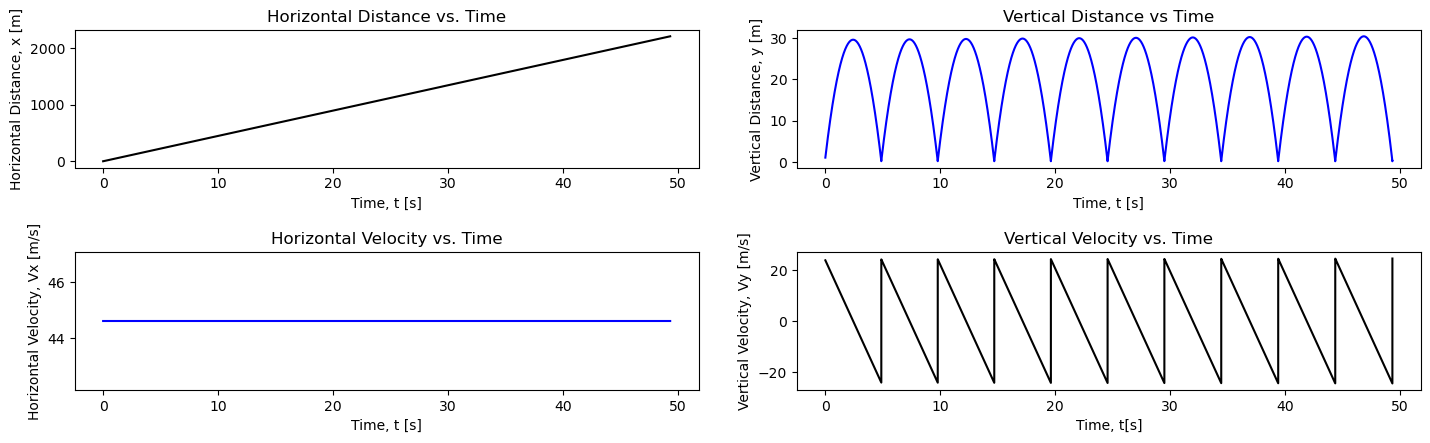

In [4]:
fig, axs = plt.subplots(2,2, figsize=(15,5))
fig.tight_layout(pad=4)
axs[0,0].set_title("Horizontal Distance vs. Time")
axs[0,0].set_xlabel("Time, t [s]")
axs[0,0].set_ylabel("Horizontal Distance, x [m]")
axs[0,0].plot(time_array, x_position_array,'k-', label='X Position')
axs[0,1].set_title("Vertical Distance vs Time")
axs[0,1].set_xlabel("Time, t [s]")
axs[0,1].set_ylabel("Vertical Distance, y [m]")
axs[0,1].plot(time_array, y_position_array, 'b-', label='Y Position')
axs[1,0].set_title("Horizontal Velocity vs. Time")
axs[1,0].set_xlabel("Time, t [s]")
axs[1,0].set_ylabel("Horizontal Velocity, Vx [m/s]")
axs[1,0].plot(time_array, x_velocity_array, 'b-', label='X Velocity')
axs[1,1].set_title("Vertical Velocity vs. Time")
axs[1,1].set_xlabel("Time, t[s]")
axs[1,1].set_ylabel("Vertical Velocity, Vy [m/s]")
axs[1,1].plot(time_array, y_velocity_array, 'k-', label='Y Velocity')
print(f"Graphs of Motion:")
plt.show()

### Model 1- Graphs of Motion Results

Although not the primary interest of this project, the graphs of motion are useful tools to qualitatively determine whether the model is behaving as expected, given the input parameters. This analysis will not be shown for each set of system parameters, however throughout the execution of this project the behaviour in the graphs of motion was used to determine if the model was behaving in line with expectations. In models beyond this inelastic collision, the graphs of motion will be turned off by default, however there exists a boolean flag in the system constants that can turn on graphs of motion for the entire project.

As shown in the above model with elastic collisions and no drag force, the horizontal velocity was constant and the change in horizontal position was linear, in line with expectations. Furthermore, the change in verticle distance exhibits quadratic behaviour, and the change in vertical velocity is in line with expectations for elastic collisions, where upon the collision the velocity changes signs but retains it's magnitude. This qualitative analysis shows that the system can successfully model projectile motion and elastic collisions in the absense of gravity.

#### Code for Graphs of Energy and Force due to Impulse

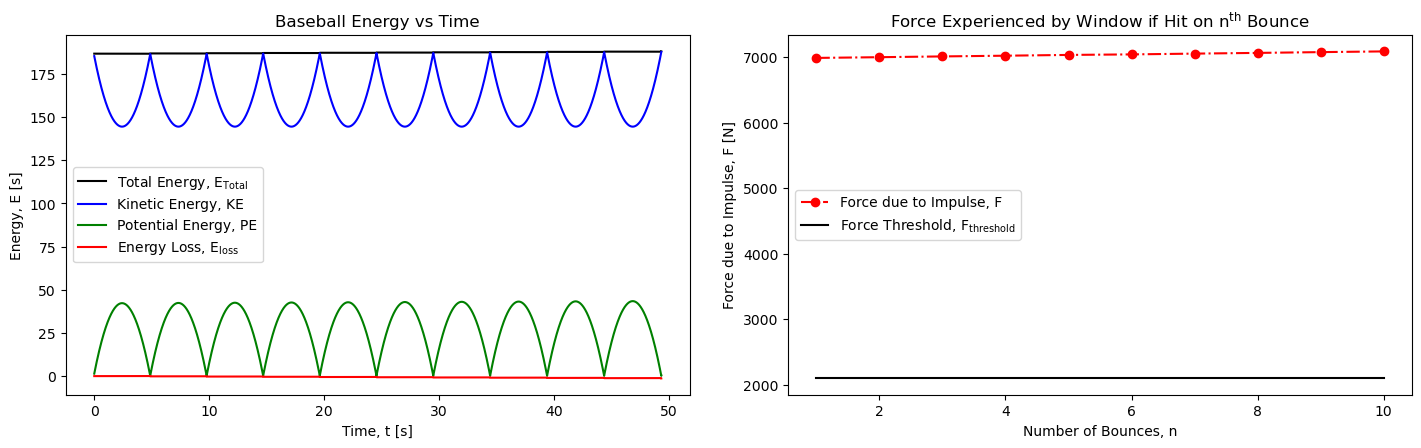

In [5]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
fig.tight_layout(pad=4)

axs[0].set_title("Baseball Energy vs Time")
axs[0].set_xlabel("Time, t [s]")
axs[0].set_ylabel("Energy, E [s]")
axs[0].plot(time_array, total_energy_array, 'k-', label="Total Energy, E$_{\\text{Total}}$")
axs[0].plot(time_array, kinetic_energy_array, 'b-', label='Kinetic Energy, KE')
axs[0].plot(time_array, potential_energy_array, 'g-', label='Potential Energy, PE')
axs[0].plot(time_array, energy_loss_array, 'r-', label='Energy Loss, E$_{\\text{loss}}$')
axs[0].legend(loc='center left')
axs[1].set_title("Force Experienced by Window if Hit on n$^{\\text{th}}$ Bounce")
axs[1].set_xlabel('Number of Bounces, n')
axs[1].set_ylabel('Force due to Impulse, F [N]')
axs[1].plot(bounce_array, impulse_array, 'ro-.', label='Force due to Impulse, F')
axs[1].plot(bounce_array, newton_force_array, 'k-', label='Force Threshold, F$_{\\text{threshold}}$')
axs[1].legend(loc='center left')
plt.show()

if verbose:
    print(f"Total Initial Energy: {total_energy_array[0]} [J]")
    print(f"Total Loss of Energy: {energy_loss_array[-1] - energy_loss_array[0]} [J]")

### Model 1 - Graphs of Energy and Force due to Impulse Results

As shown in the plots for Total Energy and Energy Loss, there is a gain of energy of approximately -1.14 joules (the ball experienced a slight gain in energy). Once again, as Euler's method is an iterative first order estimate (although we do use a system of first order equations to account for acceleration), there is some expected loss of precision over time. Although there are other iterative approaches that were alluded to in Introduction to Differential Equations that may produce better estimates (Runga-Kutta for example), Euler's method seemed sufficient for this estimation.

Though there was an energy gain of approximately 1.14 J over the course of 10 bounces, it is of note that the total energy of the ball is approximately 187 J; as such the difference in energy over 10 iterations was approximately 0.6%. As such, the model seems to appropriately approximate a perfectly elastic collision in a frictionless environment. When running the model with a smaller coefficient of restitution, and including air drag, we are expected to observe less than 10 bounces before the ball loses the capacity to break a car the window, so the magnitude of these errors should be less with less iterations of the model completed.

It of interest to note that in this idealized and simplified model, that the force due to impulse remains higher than our estimated value of force threshold with each bounce. An important distinction, however is that the energy is conserved in the *system of the ball and the ground/window*, and the energy of the ball is conserved due to the force imparted by the ground during the impulse, and the assumptions of the project assume that there is negligible change in momentum for the contact surfaces.

Another important aspect to note is that in the system models that exclude drag forces, that the kinetic energy is not expected to fall to zero because there is no horizontal force acting on the baseball; this explains the gap between the parabolic curves of kinetic and potential energies. In models that include drag forces we would expect there to be complete energy loss, although the iterations for that to occur would vary depending on input parameters.

## Model 2: Inelastic Collision on a Horizontal Window in Frictionless Environment 

Now that the model has been tested under idealized settings, the system model will be tested using a theoretical coefficient of restitution, $e = 0.55$$^{[9]}$ for the baseball such that the collision is inelastic. In this model we will expect to see a decrease in kinetic energy of the system after each bounce. The ground is assumed to be frictionless for the model and bounces are not expected to effect the horizontal components of velocity, however the return vertical velocity should be decreased by a factor of $e\cdot v_y$ after each bounce for vertical impact velocity $v_y$.

#### Code to Run Inelastic Collision on a Horizontal Window in Frictionless Environment 

In [6]:
# Set model parameters
grav_bool = True
drag_bool = False
coeff_rest = 0.55
drag_coeff = 0.5
number_of_bounces = 5

# Instantiate Object_model and System_Model for this model
object_1 = Object_Model(baseball_mass, 0, 1, exit_vectors[0], exit_vectors[1], baseball_radius, g, drag_coeff)
model = System_Model(0, [object_1], dt, g, air_density, grav_bool, drag_bool)
model.iterate_model(coeff_rest, number_of_bounces, verbose)

print(f"Finished iterations ... \n\n")

# Setting additional testing variables for model validation
impulse_force_test = 0

# Resetting arrays
x_position_array = []
y_position_array = []
x_velocity_array = []
y_velocity_array = []
kinetic_energy_array = []
potential_energy_array = []
total_energy_array = []
energy_loss_array = []
impulse_array = []
newton_force_array = []

time_array = [i * dt for i in range(len(model.objects[0].position_array))]

bounce_array = [i + 1 for i in range(len(model.objects[0].force_due_to_impulse_array))]

for i in range(len(bounce_array)):
    impulse_array.append(model.objects[0].force_due_to_impulse_array[i])
    newton_force_array.append(newton_force)

for i in range(len(model.objects[0].position_array)):
    x_position_array.append(model.objects[0].position_array[i][0])
    y_position_array.append(model.objects[0].position_array[i][1])
    x_velocity_array.append(model.objects[0].velocity_array[i][0])
    y_velocity_array.append(model.objects[0].velocity_array[i][1])
    kinetic_energy_array.append(model.objects[0].total_energy[i][0])
    potential_energy_array.append(model.objects[0].total_energy[i][1])
    total_energy_array.append(model.objects[0].total_energy[i][0] + model.objects[0].total_energy[i][1])
    energy_loss_array.append(total_energy_array[0] - total_energy_array[i])

impulse_force_test = impulse_array[0]

Finished iterations ... 




#### Code for Graphs of Motion (default: code not executed)

Although the code was not executed for the purposed of the final report it has been included such that the model's kinematic behaviour can be easily verified however the default setting is that it does not execute. In order to verify, please change the value of graphs_motion_bool in the section 'Constant Values used by System_Model and Object_Model'.

In [7]:
if graphs_motion_bool:
    fig, axs = plt.subplots(2,2, figsize=(15,5))
    fig.tight_layout(pad=4)
    axs[0,0].set_title("Horizontal Distance vs. Time")
    axs[0,0].set_xlabel("Time, t [s]")
    axs[0,0].set_ylabel("Horizontal Distance, x [m]")
    axs[0,0].plot(time_array, x_position_array,'k-', label='X Position')
    axs[0,1].set_title("Vertical Distance vs Time")
    axs[0,1].set_xlabel("Time, t [s]")
    axs[0,1].set_ylabel("Vertical Distance, y [m]")
    axs[0,1].plot(time_array, y_position_array, 'b-', label='Y Position')
    axs[1,0].set_title("Horizontal Velocity vs. Time")
    axs[1,0].set_xlabel("Time, t [s]")
    axs[1,0].set_ylabel("Horizontal Velocity, Vx [m/s]")
    axs[1,0].plot(time_array, x_velocity_array, 'b-', label='X Velocity')
    axs[1,1].set_title("Vertical Velocity vs. Time")
    axs[1,1].set_xlabel("Time, t[s]")
    axs[1,1].set_ylabel("Vertical Velocity, Vy [m/s]")
    axs[1,1].plot(time_array, y_velocity_array, 'k-', label='Y Velocity')
    print(f"Graphs of Motion:")
    plt.show()

### Model 2 - Graphs of Motion Results

The graphs of motion for this system model with inelastic collisions were in line with expectations. The horizontal change of position followed a linear fit with a constant horizontal velocity, and the vertical change in position following quadratic behaviour however with maximum vertical position decreasing after each bounce as expected with the loss of kinetic energy in the collision. 

Verification of these results can be accomplished by changing the boolean flag for 'graphs_motion_bool' to True in the model constants.

#### Code for Graphs of Energy and Force due to Impulse

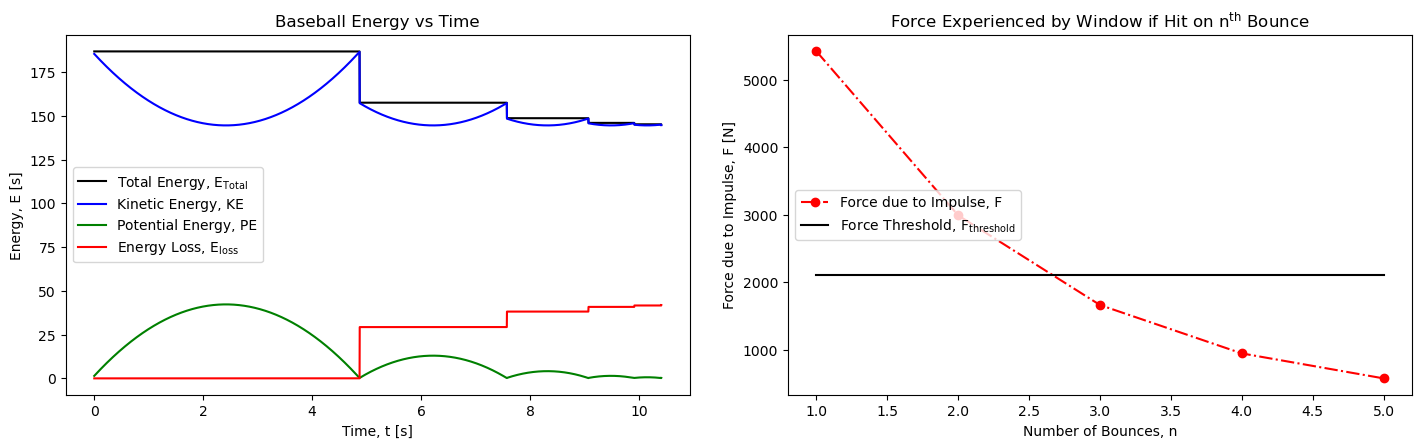

In [8]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
fig.tight_layout(pad=4)

axs[0].set_title("Baseball Energy vs Time")
axs[0].set_xlabel("Time, t [s]")
axs[0].set_ylabel("Energy, E [s]")
axs[0].plot(time_array, total_energy_array, 'k-', label="Total Energy, E$_{\\text{Total}}$")
axs[0].plot(time_array, kinetic_energy_array, 'b-', label='Kinetic Energy, KE')
axs[0].plot(time_array, potential_energy_array, 'g-', label='Potential Energy, PE')
axs[0].plot(time_array, energy_loss_array, 'r-', label='Energy Loss, E$_{\\text{loss}}$')
axs[0].legend(loc='center left')
axs[1].set_title("Force Experienced by Window if Hit on n$^{\\text{th}}$ Bounce")
axs[1].set_xlabel('Number of Bounces, n')
axs[1].set_ylabel('Force due to Impulse, F [N]')
axs[1].plot(bounce_array, impulse_array, 'ro-.', label='Force due to Impulse, F')
axs[1].plot(bounce_array, newton_force_array, 'k-', label='Force Threshold, F$_{\\text{threshold}}$')
axs[1].legend(loc='center left')
plt.show()

if verbose:
    print(f"Total Initial Energy: {total_energy_array[0]} [J]")
    print(f"Total Loss of Energy: {energy_loss_array[-1] - energy_loss_array[0]} [J]")

### Model 2 - Graphs of Energy and Force due to Impulse Results

Running the system model which includes inelastic collisions where $e=0.55$ shows several interesting result
s. First, it is worth noting that the behaviour of the energy in the system is in line with expectations for inelastic collisions in 2D space under the acceleration due to gravity and in the absence of friction. The kinetic energy of the ball and the potential energy of the ball show an exchange, with potential increasing as kinetic decrease and both exhibiting a parabolic curve. In the intervals between collisions the energy loss appears to be close to constant with minimal energy loss, and the small change in energy loss can be explained due to the loss of precision using iterative estimates.

During the collisions, it is observed that the total energy of the ball decreases and the total energy loss of the ball increases, in line with the expectations of loss of kinetic energy in inelastic collision. However in the intervals between collisions the kinetic and potential energy follow the expected interchange of energy and parabolic behaviour.

The plot of force due to impulse against number of bounces allows for more interesting and useful observations than in the elastic collision, as the number of bounces clearly had an effect on the propensity for a the baseball to break the window. In the first test model where it was an elastic collision, the force due to impulse remained above our assumed threshold for force threshold for all 10 iterated bounces, and would be expected to follow that trend as $t\rightarrow\infty$. However in this more realistic model, we can observe that by the third bounce the force due to impulse falls below the required threshold.

Though this model allows us to evaluate our research question under idealized situations, the system model still does not include the effects of air resistance and drag on the ball. As the drag force is always in opposition to the direction of the objects velocity, the inclusion of drag in the model is expected to further decrease the potential of a baseball to break a the window in relation to the number of bounces before window impact.

## Model 3: Inelastic Collision of a Smooth Baseball on a Horizontal Window with Air Friction

To further increase the realism of the system model we will create a new instance of the Object_Model and System_Model where the baseball's coefficient of restitution remains $e=0.55$$^{[9]}$, however the model will include the incorporation of drag force and the baseball will be assumed to be smooth such that the drag coefficient of the baseball, $C_d = 0.5$$^{[11]}$. The ground is again assumed to be frictionless, and as such there should not be a change in the vertical velocity due to collision with the ground, however there will be a negative acceleration to the x-component of velocity due to the force of drag opposing the motion.

For the y-component of velocity, when the object is traveling upward the acceleration due to gravity and acceleration due to the force of drag will be additive as both forces are acting against the velocity and thus are directed towards the ground, however when the object reaches it's maxima and begins travelling in the negative y-direction, the drag force will be in opposition to the force of gravity. This should result in an increased negative acceleration when the ball is travelling up (greater acceleration downward) and a decreased negative acceleration when the ball is travelling downwards

The energy in this case is not expected to remain constant in the intervals between collisions, as there is an expected loss of energy due to the work of non-conservative forces (friction/drag), and there is still expected to be a drop in total energy during each collision.

#### Code to Run Inelastic Collision of a Smooth Baseball on a Horizontal Window with Air Friction

In [9]:
# Set model parameters
grav_bool = True
drag_bool = True
coeff_rest = 0.55
drag_coeff = 0.5
number_of_bounces = 3

# Instantiate Object_model and System_Model for this model
object_1 = Object_Model(baseball_mass, 0, 1, exit_vectors[0], exit_vectors[1], baseball_radius, g, drag_coeff)
model = System_Model(0, [object_1], dt, g, air_density, grav_bool, drag_bool)
model.iterate_model(coeff_rest, number_of_bounces, verbose)

print(f"Finished iterations ... \n\n")

# Resetting arrays
x_position_array = []
y_position_array = []
x_velocity_array = []
y_velocity_array = []
kinetic_energy_array = []
potential_energy_array = []
total_energy_array = []
energy_loss_array = []
impulse_array = []
newton_force_array = []

y_max_value = 0

time_array = [i * dt for i in range(len(model.objects[0].position_array))]

bounce_array = [i + 1 for i in range(len(model.objects[0].force_due_to_impulse_array))]

for i in range(len(bounce_array)):
    impulse_array.append(model.objects[0].force_due_to_impulse_array[i])
    newton_force_array.append(newton_force)

for i in range(len(model.objects[0].position_array)):
    x_position_array.append(model.objects[0].position_array[i][0])
    y_position_array.append(model.objects[0].position_array[i][1])
    x_velocity_array.append(model.objects[0].velocity_array[i][0])
    y_velocity_array.append(model.objects[0].velocity_array[i][1])
    kinetic_energy_array.append(model.objects[0].total_energy[i][0])
    potential_energy_array.append(model.objects[0].total_energy[i][1])
    total_energy_array.append(model.objects[0].total_energy[i][0] + model.objects[0].total_energy[i][1])
    energy_loss_array.append(total_energy_array[0] - total_energy_array[i])
    if y_position_array[-1] >= y_max_value:
        y_max_value = y_position_array[-1]

Finished iterations ... 




#### Code for Graphs of Motion (default: code not executed)

Although the code was not executed for the purposed of the final report it has been included such that the model's kinematic behaviour can be easily verified however the default setting is that it does not execute. In order to verify, please change the value of graphs_motion_bool in the section 'Constant Values used by System_Model and Object_Model'.

In [10]:
if graphs_motion_bool:
    fig, axs = plt.subplots(2,2, figsize=(15,5))
    fig.tight_layout(pad=4)
    axs[0,0].set_title("Horizontal Distance vs. Time")
    axs[0,0].set_xlabel("Time, t [s]")
    axs[0,0].set_ylabel("Horizontal Distance, x [m]")
    axs[0,0].plot(time_array, x_position_array,'k-', label='X Position')
    axs[0,1].set_title("Vertical Distance vs Time")
    axs[0,1].set_xlabel("Time, t [s]")
    axs[0,1].set_ylabel("Vertical Distance, y [m]")
    axs[0,1].plot(time_array, y_position_array, 'b-', label='Y Position')
    axs[1,0].set_title("Horizontal Velocity vs. Time")
    axs[1,0].set_xlabel("Time, t [s]")
    axs[1,0].set_ylabel("Horizontal Velocity, Vx [m/s]")
    axs[1,0].plot(time_array, x_velocity_array, 'b-', label='X Velocity')
    axs[1,1].set_title("Vertical Velocity vs. Time")
    axs[1,1].set_xlabel("Time, t[s]")
    axs[1,1].set_ylabel("Vertical Velocity, Vy [m/s]")
    axs[1,1].plot(time_array, y_velocity_array, 'k-', label='Y Velocity')
    print(f"Graphs of Motion:")
    plt.show()

### Model 3 - Graphs of Motion Results

The graphs of motion for this system of inelastic collisions with included non-conservative forces again was in line with expectations. The horizontal distance, rather than being linear, begins with a relatively large posive rate of change that is concave downwards, showing a decreasing rate of increase in x-position over time. The horizontal velocity collaborates this, showing a decreasingly negative horizontal velocity that levels out as $t$ increases. As the horizontal acceleration is a function of horizontal velocity (drag force is velocity dependent), the magnitude of the acceleration is largest at the beginning of the ball's motion and decreases over time as the velocity decrease.

The graph of vertical distance over time is also in line with expectations. With the inclusion of drag, the vertical acceleration is also a function of the vertical velocity - after the batter makes contact with the baseball the vertical velocity is initially at it's highest magnitude, with the magnitude decreasing over time as the velocity itself decreases. The decrease in velocity is non-linear as expected, however it is interesting to note that as the magnitude of the velocity decreases over time the apparent concavity of the velocity graph also decreases. As the vertical velocity decreases after bounces, each interval in between may be better and better approximated linearly.

#### Code for Graphs of Energy and Force due to Impulse

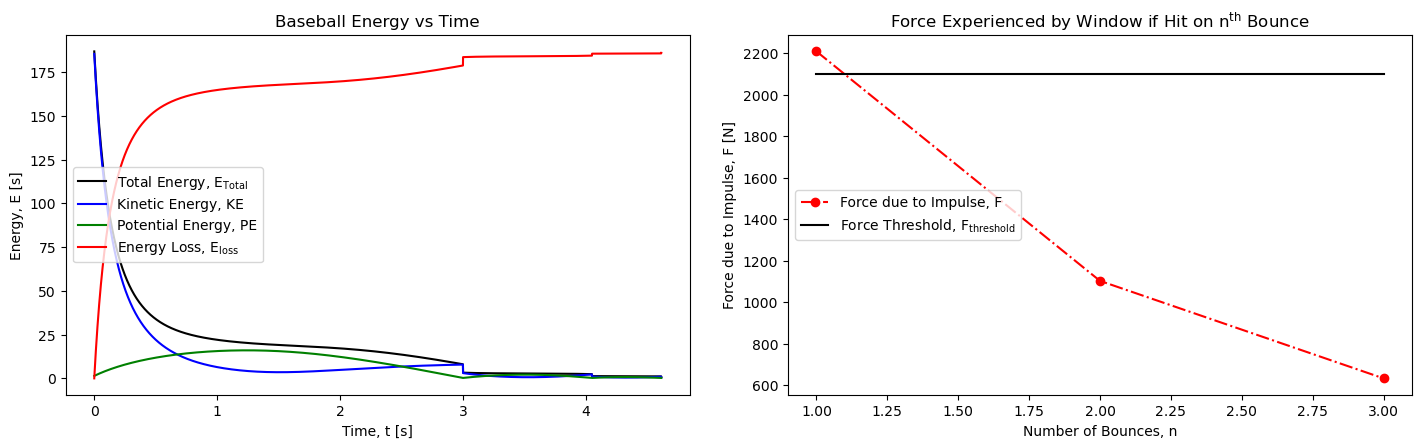

In [11]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
fig.tight_layout(pad=4)

axs[0].set_title("Baseball Energy vs Time")
axs[0].set_xlabel("Time, t [s]")
axs[0].set_ylabel("Energy, E [s]")
axs[0].plot(time_array, total_energy_array, 'k-', label="Total Energy, E$_{\\text{Total}}$")
axs[0].plot(time_array, kinetic_energy_array, 'b-', label='Kinetic Energy, KE')
axs[0].plot(time_array, potential_energy_array, 'g-', label='Potential Energy, PE')
axs[0].plot(time_array, energy_loss_array, 'r-', label='Energy Loss, E$_{\\text{loss}}$')
axs[0].legend(loc='center left')
axs[1].set_title("Force Experienced by Window if Hit on n$^{\\text{th}}$ Bounce")
axs[1].set_xlabel('Number of Bounces, n')
axs[1].set_ylabel('Force due to Impulse, F [N]')
axs[1].plot(bounce_array, impulse_array, 'ro-.', label='Force due to Impulse, F')
axs[1].plot(bounce_array, newton_force_array, 'k-', label='Force Threshold, F$_{\\text{threshold}}$')
axs[1].legend(loc='center left')
plt.show()

if verbose:
    print(f"Total Initial Energy: {total_energy_array[0]} [J]")
    print(f"Total Loss of Energy: {energy_loss_array[-1] - energy_loss_array[0]} [J]")

### Model 3 - Graphs of Energy and Force due to Impulse Results

After running the system model in which the coefficient of restition for the baseball was $e=0.55$, the drag coefficient of the baseball was $C_d = 0.5$ the resulting graphs of energy and of force due to impulse against number of bounces allow us to make some interesting observations about the model.

It is observed that the kinetic energy experiences a decay over time during the intervals between bounces, indicating that there is significant loss of kinetic energy due to the force of drag. Much of the kinetic energy of the ball is lost to drag before the first bounce. Although the total initial energy has been the same for each instance of the system model (290 J), a key difference between the models ignoring drag and the models including drag can be witnessed in the force due to impulse of the first bounce. Without drag the first bounce of the baseball produced an estimated force due to impulse of over 7 kN, however when drag was included in the model the first bounce produced a force just over 2200 N, barely exceeding our assumed value for force threshold.

Without the force of drag the ball required 2 initial bounces to avoid breaking the window, however with the inclusion of drag force we can see that the ball no longer posseses the required energy after the first bounce. As such we can observe that the inclusion of drag forces is proportional to a decrease in energy over time, and a decrease in number of bounces required before the ball no longer breaks the glass.

## Model 4: Inelastic Collision of a Rough Baseball on a Horizontal Window with Air Friction

Now we will observe the effects of the ball's drag coefficient, $C_d$, on the number of bounces before the baseball no longer breaks the glass. A new instance of the Object_Model and System_Model will be created where $e=0.55$ however the baseball will be modeled as rough such that the drag coefficient $C_d = 0.3$. The ground is again assumed to be frictionless, and as such there should not be a change in the horizontal velocity *due to collision with the ground*, however there will be a negative acceleration to the x-component of velocity due to the force of drag opposing the motion.

The graphs of motion and the graphs of energy are expected to observe similar behaviours as in the above model with the smooth baseball, however with a decreased coefficient of drag we are expecting some changes in the resulting behaviour. As a baseball is not perfectly smooth due to the presence of stitches and manufacturing imperfections, a lower drag coefficient is likely more in line with observed real-world behaviour. Functionally, this will cause a decrease in the force of drag, and thus slow the loss of energy of the ball due to the work of this non-conservative force. The explanation for why this occurs is that the roughness causes disturbances in the flow of air around the ball, and decreases the drag the ball experiences due to this interruption of laminar flow$^{[11]}$

#### Code to Run Inelastic Collision of a Rough Baseball on a Horizontal Window with Air Friction

In [12]:
# Set model parameters
grav_bool = True
drag_bool = True
verbose = False
coeff_rest = 0.55
drag_coeff = 0.3
number_of_bounces = 3

# Instantiate Object_model and System_Model for this model
object_1 = Object_Model(baseball_mass, 0, 1, exit_vectors[0], exit_vectors[1], baseball_radius, g, drag_coeff)
model = System_Model(0, [object_1], dt, g, air_density, grav_bool, drag_bool)
model.iterate_model(coeff_rest, number_of_bounces, verbose)

print(f"Finished iterations ... \n\n")

# Resetting arrays
x_position_array = []
y_position_array = []
x_velocity_array = []
y_velocity_array = []
kinetic_energy_array = []
potential_energy_array = []
total_energy_array = []
energy_loss_array = []
impulse_array = []
newton_force_array = []

time_array = [i * dt for i in range(len(model.objects[0].position_array))]

bounce_array = [i + 1 for i in range(len(model.objects[0].force_due_to_impulse_array))]

for i in range(len(bounce_array)):
    impulse_array.append(model.objects[0].force_due_to_impulse_array[i])
    newton_force_array.append(newton_force)

for i in range(len(model.objects[0].position_array)):
    x_position_array.append(model.objects[0].position_array[i][0])
    y_position_array.append(model.objects[0].position_array[i][1])
    x_velocity_array.append(model.objects[0].velocity_array[i][0])
    y_velocity_array.append(model.objects[0].velocity_array[i][1])
    kinetic_energy_array.append(model.objects[0].total_energy[i][0])
    potential_energy_array.append(model.objects[0].total_energy[i][1])
    total_energy_array.append(model.objects[0].total_energy[i][0] + model.objects[0].total_energy[i][1])
    energy_loss_array.append(total_energy_array[0] - total_energy_array[i])

Finished iterations ... 




#### Code for Graphs of Motion (default: code not executed)

Although the code was not executed for the purposed of the final report it has been included such that the model's kinematic behaviour can be easily verified however the default setting is that it does not execute. In order to verify, please change the value of graphs_motion_bool in the section 'Constant Values used by System_Model and Object_Model'.

In [13]:
if graphs_motion_bool:
    fig, axs = plt.subplots(2,2, figsize=(15,5))
    fig.tight_layout(pad=4)
    axs[0,0].set_title("Horizontal Distance vs. Time")
    axs[0,0].set_xlabel("Time, t [s]")
    axs[0,0].set_ylabel("Horizontal Distance, x [m]")
    axs[0,0].plot(time_array, x_position_array,'k-', label='X Position')
    axs[0,1].set_title("Vertical Distance vs Time")
    axs[0,1].set_xlabel("Time, t [s]")
    axs[0,1].set_ylabel("Vertical Distance, y [m]")
    axs[0,1].plot(time_array, y_position_array, 'b-', label='Y Position')
    axs[1,0].set_title("Horizontal Velocity vs. Time")
    axs[1,0].set_xlabel("Time, t [s]")
    axs[1,0].set_ylabel("Horizontal Velocity, Vx [m/s]")
    axs[1,0].plot(time_array, x_velocity_array, 'b-', label='X Velocity')
    axs[1,1].set_title("Vertical Velocity vs. Time")
    axs[1,1].set_xlabel("Time, t[s]")
    axs[1,1].set_ylabel("Vertical Velocity, Vy [m/s]")
    axs[1,1].plot(time_array, y_velocity_array, 'k-', label='Y Velocity')
    print(f"Graphs of Motion:")
    plt.show()

### Model 4 - Graphs of Motion Results

The graphs of motion for this system of inelastic collisions with included non-conservative forces again was in line with expectations. The rates of change along each axis followed similar patterns in the collision prior, where the only difference between the models was the reduction in the baseball's drag coefficient from $C_d = 0.5$ to $C_d = 0.3$.

Changes to note between this model and the previous model is that the reduction of $C_d$ allowed for the ball to travel a greater distance in the horizontal direction as well as have a vertical maxima that was higher than the previous model. This is in line with expectations as a decrease in $C_d$ is expected to be proportional to a decrease in the drag force, and therefore a decrease in work done by non-conservative forces and a slower loss of energy than the previous model with the smooth baseball.

#### Code for Graphs of Energy and Force due to Impulse

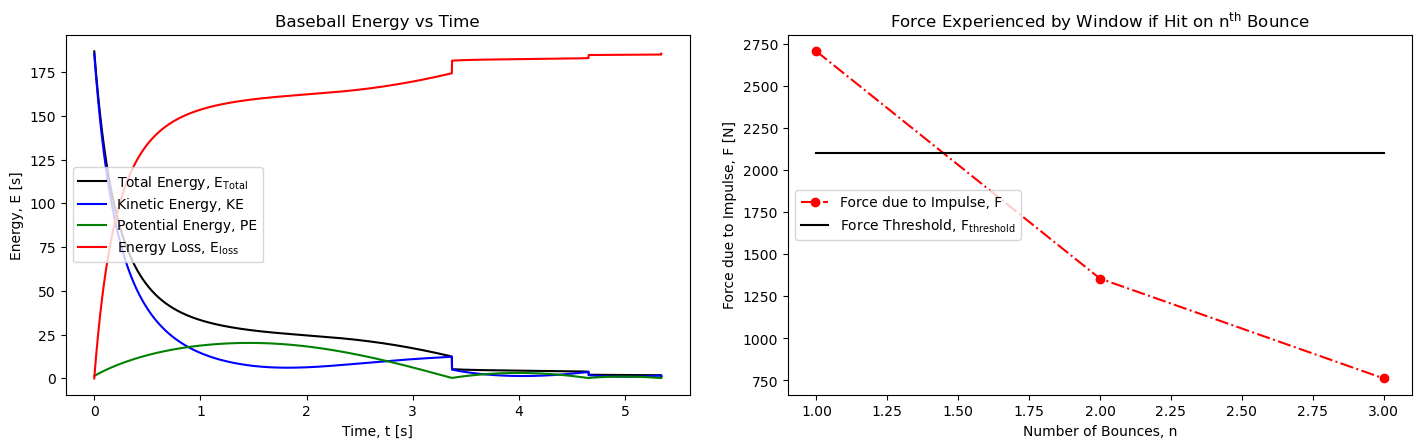

In [14]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
fig.tight_layout(pad=4)

axs[0].set_title("Baseball Energy vs Time")
axs[0].set_xlabel("Time, t [s]")
axs[0].set_ylabel("Energy, E [s]")
axs[0].plot(time_array, total_energy_array, 'k-', label="Total Energy, E$_{\\text{Total}}$")
axs[0].plot(time_array, kinetic_energy_array, 'b-', label='Kinetic Energy, KE')
axs[0].plot(time_array, potential_energy_array, 'g-', label='Potential Energy, PE')
axs[0].plot(time_array, energy_loss_array, 'r-', label='Energy Loss, E$_{\\text{loss}}$')
axs[0].legend(loc='center left')
axs[1].set_title("Force Experienced by Window if Hit on n$^{\\text{th}}$ Bounce")
axs[1].set_xlabel('Number of Bounces, n')
axs[1].set_ylabel('Force due to Impulse, F [N]')
axs[1].plot(bounce_array, impulse_array, 'ro-.', label='Force due to Impulse, F')
axs[1].plot(bounce_array, newton_force_array, 'k-', label='Force Threshold, F$_{\\text{threshold}}$')
axs[1].legend(loc='center left')
plt.show()

if verbose:
    print(f"Total Initial Energy: {total_energy_array[0]} [J]")
    print(f"Total Loss of Energy: {energy_loss_array[-1] - energy_loss_array[0]} [J]")

### Model 4 - Graphs of Energy and Force due to Impulse Results

After running the system model in which the coefficient of restitution $e = 0.55$ and the drag coefficient for the rough baseball was $C_d = 0.3$, the graphs produced of energy and the force due to impulse allow for us to make some interesting observations, both in relation to the models without drag as well as with the model where $C_d = 0.5$.

The contrast between this model and the models without drag is similar to the differences between the prior model and the models without drag; this model again shows a loss of kinetic energy as energy is lost due drag, and again much of the energy is lost before the first bounce occurs. In comparison to the models excluding drag, there was also an observed reduction in the number of bounces required before the ball fails to break the window from 2 to 1.

There are, however, also differences between the two models that include drag. In this model with $C_d=0.3$, it was observed that the force due to impulse of the first bounce was higher than the prior model with $C_d=0.5$. The prior model had an initial force of approximately 2.2 kN whereas this model's initial force was just below 2.75 kN. This follows the expectations, as the non-conservative force in this model was reduced proportionally in line with the reduction in $C_d$ value. However in spit of these differences by the second bounce both models show that the baseball fails to break the window with our assumed force threshold. Although the model with the rough baseball loses energy slower than the model with the smooth baseball, we do not observe a categorical outcome of number of bounces versus capacity of a ball to break the window under the assumptions in our model

## Model 5: Inelastic Collision of a Rough Baseball on an Angled Window Both With and Without Air Friction

The final iteration of our system will observe the effects of window angle on the force due to impulse. In this we will create two system models for inelastic collisions with the second model also including drag force on a rough baseball. The coefficient of restitution will still be defined as $e=0.55$ and for the second model the drag coefficient will be $C_d = 0.3$, that of a rough baseball.

For both models the trajectory and the force due to impact will be calculated using different methods. For both models the trajectory of the ball for each successive bounce will be calculated as though the ball is bouncing on a horizontal surface: for the model without drag force the horizontal velocity will be unaffected by the bounces and will be constant over time; and for the model with drag force the horizontal velocity will be unaffected by the bounces but will be affected by the drag force. This allows the simulation to calculate the force due to impact on successive bounces without having to restart upon every window contact where force due to impulse is calculated. However upon each bounce, the force due to impact will be calculated as though the ball is hitting an angled window not parallel to the ground, with note that this *does not* affect the velocity components or trajectory of the ball. This will be done using the normal vector $\vec{n}$ as defined for the window surface with the angle $\theta = 135\degree$ with respect to the $x-$axis.

For the system without drag force, we expect that the horizontal component of velocity will give large contributions towards the force due to impulse. This is due to their being no horizontal acceleration, such that the horizontal velocity remains constant from the moment of launch. The vertical velocity is still expected to decrease upon each bounce as the collision is inelastic and some vertical speed will be lost as a function of the coefficient of restitution. We also expect the force due to impulse to approach a asymptotically approach a minimum, although the minimum should be reached when the vertical velocity component reaches zero; this is again due to the constant horizontal velocity. In order to better observe this expected levelling of the force due to impulse, we have increased the number of bounces for this simulation to 10.

For the system with drag force, it was previously observed that the drag force had a drastic effect on the kinetic energy of the system. As such, we would expect there to still be a rapid decrease in the force due to impulse, however in comparison to the previous model using the same drag force and coefficient we would still expect their to by high force due to impulse experienced by the window due to the contribution towards the force by the $x-$component of momentum.

As the model still calculates the projectile motion as it was in the system with a horizontal window, we do not expect to see any changes in the graphs of motion for these two systems. As the graphs of the system energies are determined by the motion of the ball (potential energy dependent on height, kinetic on velocity), we do not expect changes to the graphs of energies as the projectile motion of the ball was not changed in the simulation, only the calculation of the force due impulse.

#### Code to Run Inelastic Collision of a Rough Baseball on an Angled Window Both With and Without Air Friction

In [15]:
# Set model parameters
grav_bool = True
verbose = False
coeff_rest = 0.55
drag_coeff = 0.3
number_of_bounces = 3
window_angle = 135

# Instantiate Object_model and System_Model for this model
object_1 = Object_Model(baseball_mass, 0, 1, exit_vectors[0], exit_vectors[1], baseball_radius, g, drag_coeff)
object_2 = Object_Model(baseball_mass, 0, 1, exit_vectors[0], exit_vectors[1], baseball_radius, g, drag_coeff)

model1 = System_Model(0, [object_1], dt, g, air_density, grav_bool, False, window_angle)
model2 = System_Model(0, [object_2], dt, g, air_density, grav_bool, True, window_angle)

model1.iterate_model(coeff_rest, 10, verbose)
model2.iterate_model(coeff_rest, number_of_bounces, verbose)

print(f"Finished iterations ... \n\n")

# Resetting arrays
x_position_array1 = []
y_position_array1 = []
x_velocity_array1 = []
y_velocity_array1 = []
kinetic_energy_array1 = []
potential_energy_array1 = []
total_energy_array1 = []
energy_loss_array1 = []
impulse_array1 = []
newton_force_array1 = []

x_position_array2 = []
y_position_array2 = []
x_velocity_array2 = []
y_velocity_array2 = []
kinetic_energy_array2 = []
potential_energy_array2 = []
total_energy_array2 = []
energy_loss_array2 = []
impulse_array2 = []
newton_force_array2 = []

time_array1 = [i * dt for i in range(len(model1.objects[0].position_array))]
time_array2 = [i * dt for i in range(len(model2.objects[0].position_array))]

bounce_array1 = [i + 1 for i in range(len(model1.objects[0].force_due_to_impulse_array))]
bounce_array2 = [i + 1 for i in range(len(model2.objects[0].force_due_to_impulse_array))]

for i in range(len(bounce_array1)):
    impulse_array1.append(model1.objects[0].force_due_to_impulse_array[i])
    newton_force_array1.append(newton_force)

for i in range(len(bounce_array2)):
    impulse_array2.append(model2.objects[0].force_due_to_impulse_array[i])
    newton_force_array2.append(newton_force)

for i in range(len(model1.objects[0].position_array)):
    x_position_array1.append(model1.objects[0].position_array[i][0])
    y_position_array1.append(model1.objects[0].position_array[i][1])
    x_velocity_array1.append(model1.objects[0].velocity_array[i][0])
    y_velocity_array1.append(model1.objects[0].velocity_array[i][1])
    kinetic_energy_array1.append(model1.objects[0].total_energy[i][0])
    potential_energy_array1.append(model1.objects[0].total_energy[i][1])
    total_energy_array1.append(model1.objects[0].total_energy[i][0] + model1.objects[0].total_energy[i][1])
    energy_loss_array1.append(total_energy_array1[0] - total_energy_array1[i])

for i in range(len(model2.objects[0].position_array)):
    x_position_array2.append(model2.objects[0].position_array[i][0])
    y_position_array2.append(model2.objects[0].position_array[i][1])
    x_velocity_array2.append(model2.objects[0].velocity_array[i][0])
    y_velocity_array2.append(model2.objects[0].velocity_array[i][1])
    kinetic_energy_array2.append(model2.objects[0].total_energy[i][0])
    potential_energy_array2.append(model2.objects[0].total_energy[i][1])
    total_energy_array2.append(model2.objects[0].total_energy[i][0] + model2.objects[0].total_energy[i][1])
    energy_loss_array2.append(total_energy_array2[0] - total_energy_array2[i])

Finished iterations ... 




#### Code for Graphs of Motion (default: code not executed)

Although the code was not executed for the purposed of the final report it has been included such that the model's kinematic behaviour can be easily verified however the default setting is that it does not execute. In order to verify, please change the value of graphs_motion_bool in the section 'Constant Values used by System_Model and Object_Model'.

In [16]:
if graphs_motion_bool:
    fig1, axs1 = plt.subplots(2,2, figsize=(15,5))
    fig1.tight_layout(pad=4)
    axs1[0,0].set_title("Horizontal Distance vs. Time - No Drag Force")
    axs1[0,0].set_xlabel("Time, t [s]")
    axs1[0,0].set_ylabel("Horizontal Distance, x [m]")
    axs1[0,0].plot(time_array1, x_position_array1,'k-', label='X Position')
    axs1[0,1].set_title("Vertical Distance vs Time - No Drag Force")
    axs1[0,1].set_xlabel("Time, t [s]")
    axs1[0,1].set_ylabel("Vertical Distance, y [m]")
    axs1[0,1].plot(time_array1, y_position_array1, 'b-', label='Y Position')
    axs1[1,0].set_title("Horizontal Velocity vs. Time - No Drag Force")
    axs1[1,0].set_xlabel("Time, t [s]")
    axs1[1,0].set_ylabel("Horizontal Velocity, Vx [m/s]")
    axs1[1,0].plot(time_array1, x_velocity_array1, 'b-', label='X Velocity')
    axs1[1,1].set_title("Vertical Velocity vs. Time - No Drag Force")
    axs1[1,1].set_xlabel("Time, t[s]")
    axs1[1,1].set_ylabel("Vertical Velocity, Vy [m/s]")
    axs1[1,1].plot(time_array1, y_velocity_array1, 'k-', label='Y Velocity')
    print(f"Graphs of Motion - No Drag Force:")
    plt.show()

    fig2, axs2 = plt.subplots(2,2, figsize=(15,5))
    fig2.tight_layout(pad=4)
    axs2[0,0].set_title("Horizontal Distance vs. Time - With Drag Force")
    axs2[0,0].set_xlabel("Time, t [s]")
    axs2[0,0].set_ylabel("Horizontal Distance, x [m]")
    axs2[0,0].plot(time_array2, x_position_array2,'k-', label='X Position')
    axs2[0,1].set_title("Vertical Distance vs Time - With Drag Force")
    axs2[0,1].set_xlabel("Time, t [s]")
    axs2[0,1].set_ylabel("Vertical Distance, y [m]")
    axs2[0,1].plot(time_array2, y_position_array2, 'b-', label='Y Position')
    axs2[1,0].set_title("Horizontal Velocity vs. Time - With Drag Force")
    axs2[1,0].set_xlabel("Time, t [s]")
    axs2[1,0].set_ylabel("Horizontal Velocity, Vx [m/s]")
    axs2[1,0].plot(time_array2, x_velocity_array2, 'b-', label='X Velocity')
    axs2[1,1].set_title("Vertical Velocity vs. Time - With Drag Force")
    axs2[1,1].set_xlabel("Time, t[s]")
    axs2[1,1].set_ylabel("Vertical Velocity, Vy [m/s] - With Drag Force")
    axs2[1,1].plot(time_array2, y_velocity_array2, 'k-', label='Y Velocity')
    print(f"Graphs of Motion - With Drag Force:")
    plt.show()

### Model 5 - Graphs of Motion Results

The graphs of motion were in line with expectations; as the system model does not take into account the window angle used for calculating force due to impulse and instead simulates the ball trajectory as though bouncing off the parking lot each time, the results for the graphs of motion were expected to be identical to those produced in the system model above.

#### Code for Graphs of Energy and Force due to Impulse

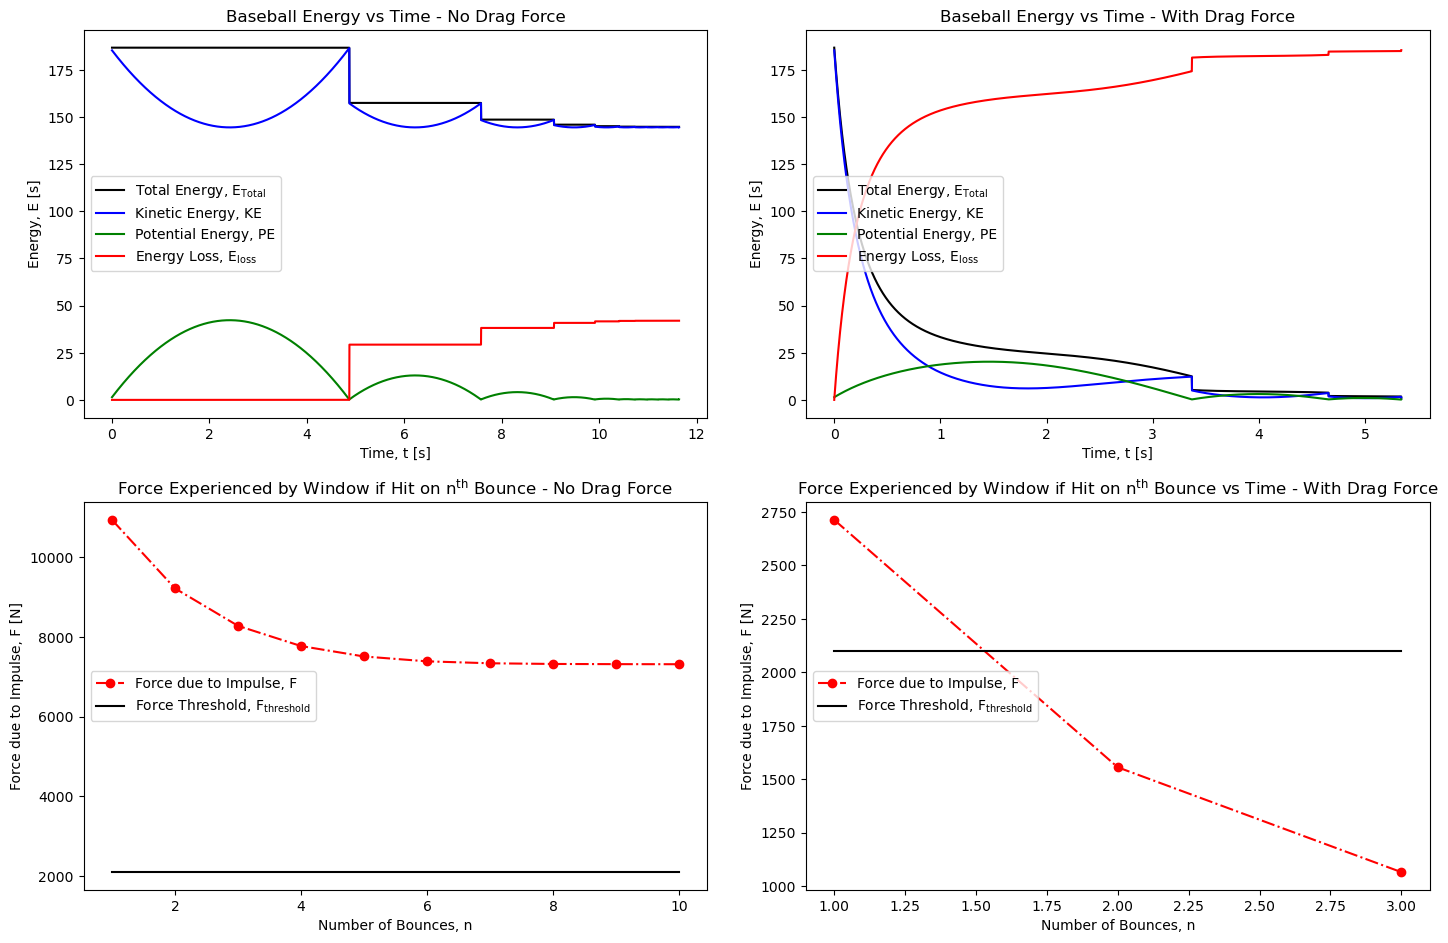

In [17]:
fig1, axs1 = plt.subplots(2,2, figsize=(15,10))
fig1.tight_layout(pad=4)

if verbose:
    print(f"Total Initial Energy: {total_energy_array[0]} [J]")
    print(f"Total Loss of Energy: {energy_loss_array[-1] - energy_loss_array[0]} [J]")

axs1[0][0].set_title("Baseball Energy vs Time - No Drag Force")
axs1[0][0].set_xlabel("Time, t [s]")
axs1[0][0].set_ylabel("Energy, E [s]")
axs1[0][0].plot(time_array1, total_energy_array1, 'k-', label="Total Energy, E$_{\\text{Total}}$")
axs1[0][0].plot(time_array1, kinetic_energy_array1, 'b-', label='Kinetic Energy, KE')
axs1[0][0].plot(time_array1, potential_energy_array1, 'g-', label='Potential Energy, PE')
axs1[0][0].plot(time_array1, energy_loss_array1, 'r-', label='Energy Loss, E$_{\\text{loss}}$')
axs1[0][0].legend(loc='center left')
axs1[1][0].set_title("Force Experienced by Window if Hit on n$^{\\text{th}}$ Bounce - No Drag Force")
axs1[1][0].set_xlabel('Number of Bounces, n')
axs1[1][0].set_ylabel('Force due to Impulse, F [N]')
axs1[1][0].plot(bounce_array1, impulse_array1, 'ro-.', label='Force due to Impulse, F')
axs1[1][0].plot(bounce_array1, newton_force_array1, 'k-', label='Force Threshold, F$_{\\text{threshold}}$')
axs1[1][0].legend(loc='center left')


axs1[0][1].set_title("Baseball Energy vs Time - With Drag Force")
axs1[0][1].set_xlabel("Time, t [s]")
axs1[0][1].set_ylabel("Energy, E [s]")
axs1[0][1].plot(time_array2, total_energy_array2, 'k-', label="Total Energy, E$_{\\text{Total}}$")
axs1[0][1].plot(time_array2, kinetic_energy_array2, 'b-', label='Kinetic Energy, KE')
axs1[0][1].plot(time_array2, potential_energy_array2, 'g-', label='Potential Energy, PE')
axs1[0][1].plot(time_array2, energy_loss_array2, 'r-', label='Energy Loss, E$_{\\text{loss}}$')
axs1[0][1].legend(loc='center left')
axs1[1][1].set_title("Force Experienced by Window if Hit on n$^{\\text{th}}$ Bounce vs Time - With Drag Force")
axs1[1][1].set_xlabel('Number of Bounces, n')
axs1[1][1].set_ylabel('Force due to Impulse, F [N]')
axs1[1][1].plot(bounce_array2, impulse_array2, 'ro-.', label='Force due to Impulse, F')
axs1[1][1].plot(bounce_array2, newton_force_array2, 'k-', label='Force Threshold, F$_{\\text{threshold}}$')
axs1[1][1].legend(loc='center left')
plt.show()

if verbose:
    print(f"Total Initial Energy - No Drag: {total_energy_array1[0]} [J]")
    print(f"Total Loss of Energy - No Drag: {energy_loss_array1[-1] - energy_loss_array1[0]} [J]\n")
    print(f"Total Initial Energy - With Drag: {total_energy_array2[0]} [J]")
    print(f"Total Loss of Energy - With Drag: {energy_loss_array2[-1] - energy_loss_array2[0]} [J]")

### Model 5 - Graphs of Energy and Force due to Impulse Results

The final iterations of the system model were completed, both with and without drag force, and using an angled window. The coefficient of restitution for both system collisions was set at $e = 0.55$, and for the system including drag force the drag coefficient used was that of a rough baseball where $C_d = 0.3$. The normal vector defined for the window had an angle of $\theta = 135\degree$ with respect to the positive $x-$axis.

Our graphs of of baseball energy against time in both system models match that of their previous respective systems (with note that the number of bounces was increased for the no drag simulation from 3 bounces to 10 bounces). This matches our expectations listed above.

For the system without the included drag force, it was observed that the force due to impulse did approach a minimum value due to the constant horizontal velocity. As there were no forces acting on the ball in the horizontal direction and thus no acceleration, there will always be a non-zero $p_x$ component that will contribute to force due to impulse. Furthermore, from appendix A1, we can see the initial velocity components 
$$
\begin{align}
    v_{x_0} &= 44.6 \text{ ms}^{-1} \\
    v_{y_0} &= 23.7 \text{ ms}^{-1}
\end{align}
$$
As the horizontal velocity is much greater than the vertical velocity the magnitude of the increase in the force due to impulse was also as expected, as well as the magnitude of the minimum force due to impulse. The force remained above the threshold of window tolerance for the entire duration of the simulation, and would remain above the threshold as $t\to\infty$ as the model excludes surface friction.

For the system that included drag force the force due to impulse was affected by the rapid loss of kinetic energy, however we did observer that the contribution to the force from the $x-$component of momentum did cause an increase in the force experienced. Of particular interest was the force during second and third bounce. In the drag model without window angle the force experienced during those bounces was less than that with an angled window: the second bounce without an angled window imparted a force between $1250N - 1500N$, whereas the second bounce with an angled window had a force above $1500N$; similarly, the third bounce without angled windows had a force $\approx 750N$, whereas the second bounce with an angled window had a force above $1000N$. This is in line with our expectations for the system with the horizontal momentum now contributing towards the force due to impulse. Though the inclusion of an angled window did not change the categorical outcome of the simulation it was of interest to note how the angled window contributed towards the force experienced during impulse.

## Conclusion

The research question that this model set to investigate was the effects that a baseball bouncing prior to window impact has on the ability of the ball to break the window. The model was further used to investigate the effects that increasing the realism of the model has on the behaviour of the ball, with the initial model state that of an elastic collision in absence of non-conservative forces and successive models icrementally adding inelasticity, drag force on an idealized ball, and drag force on a ball with some more realistic assumptions regarding how the ball experiences drag.

It was found throughout these iterations that the models behaved as expected and the values produced were within reasonable tolerance of our theoretic expectations. As such, what was observed was that bouncing before window impact had a deleterious affect on the balls ability to break the window, with it's ability decreasing with each successive bounce. With the addition of inelasticity, the number of bounces after which the ball would still break the window was reduced from infinite in the elastic model with conserved energy, to two bounces in the model with inelastic collisions. Furthermore, with the addition of drag, both the rough and smooth basebally models required a direct hit in order for the ball to break the window. Though the categorical outcome was identical in both models with drag, it was also observed that the model with the lower and more realistic drag force produced more force during the impulse than the model with an idealize spherical ball.

Though the assumption of window force threshold was the largest and weakest assumption made during the model creation, the model itself was designed in a way to maintain generality and expandability, and there are several directions for which further development and implementation may occur. For better assumptions as to whether impact causes destruction it would be useful to implement deformability of the ball and contact mechanics to determine how the surface area of contact changes over the time of contact during impulse; with this the pressure of the impact would be able to be determined and as most research and testing into window strength deals with pressure this would allow for better assumptions and modelling. As well, due to the construction of the object and system classes, this would allow for determining categorical outcomes of collisions between a range of projectiles and materials by instantiation of the object class with different values mass, radius, drag coefficient, etc., and by changing the pressure required for breakability of the surface.

Another area for potential further development is to implement the ability to set different heights for the final contact surface such that they system could then model more accurately for vehicles of different makes and models. This could be accomplished by creating an Object_Model class function, such as next_impulse_force, that intakes a force threshold; if the calculated force due to impulse at the height of the window remains larger than the tolerance, the ball could be allowed to continue towards the ground to make contact and begin it's next bounce and otherwise we could stop the iteration. There is also potential for further development towards contact mechanics when the physics to implement this is within our grasp. Including contact mechanics, such as the deformation of the ball during impact and it's relation to surface area as a function of time, would allow both for better approximations on whether a window breaks due to pressure, as well as implementing surface friction into the model.

## References
_(In addition to citations for any python packages used beyond our standard ones, list the sources for any data or literature cited in your project. Additionally, you must also cite the sources for any code that you found on the internet or from peers.)_

**Citations - Python API Reference Pages**

1. Numpy Linear Algebra Package API Reference Page - https://numpy.org/doc/stable/reference/routines.linalg.html
2. Matplotlib Axes Legend API Reference Page - https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
3. Python Docs - Classes - https://docs.python.org/3/tutorial/classes.html
4. Numpy Array API Reference Page - https://numpy.org/doc/stable/reference/generated/numpy.array.html
5. Numpy Inner Produce API Reference Page - https://numpy.org/doc/2.0/reference/generated/numpy.inner.html

**Citations - Physical Theories, Equations and Assumptions**

6. MLB Equipment Rulebook - https://img.mlbstatic.com/mlb-images/image/upload/mlb/atcjzj9j7wrgvsm8wnjq.pdf 
7. MLB Exit Velocity Statistics (2024 season) - https://baseballsavant.mlb.com/statcast_hit_probability?year=2024&type=ev
8. MLB Launch Angle Statistics (2024 season) - https://baseballsavant.mlb.com/statcast_hit_probability?year=2024&type=la and
9. Coefficient of Restitution for Baseball - https://tht.fangraphs.com/the-physics-of-cor-and-other-measures-of-bounciness/
10. NASA - Drag Equation -  https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/drag-equation/
11. NASA - Drag of a Baseball - https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/drag-on-a-baseball/
12. Car Window Force Threshold - https://www.gamedev.net/forums/topic/287542-how-hard-do-you-have-to-smash-into-a-car-windscreen-for-it-to-break/2808960/
13. Air Density - https://en.wikipedia.org/wiki/Density_of_air
14. $\Delta t$ for Baseball Impulse - https://www.acs.psu.edu/drussell/bats/impulse.htm
15. Contact Mechanics Wikipedia - https://en.wikipedia.org/wiki/Contact_mechanics
16. Contact Mechanics - https://library.oapen.org/bitstream/id/2ea98fbf-d001-4dff-8a63-d3555f559b5b/1006864.pdf
17. Ground Reaction Forces for Running - https://runnersweb.com/running/Journal_of_Applied_Biomechanics_article.pdf
18. Human Body Weight Data - https://en.wikipedia.org/wiki/Human_body_weight
19. Man Walks on Car Windshield and Breaks it - https://www.youtube.com/watch?v=PWApfs4aI2Y
20. Ground Reaction Forces for Jumping - https://pmc.ncbi.nlm.nih.gov/articles/PMC3761745/

## Appendix 1: Code validation

### A1.1: Comparison of simulation results with by-hand calculations

**Determing whether projectile behaves as expected in absense of drag**

In [18]:
# Print some useful constants that were used in the by-hand calculations below

print(f"Constants used:\n Mass: {object_1.mass} kg\n Radius: {object_1.radius} m\n Initial Height: {object_1.position_array[0][1]} m \n Initial Velocity x: {exit_vectors[0]} m/s \n Initial Velocity y: {exit_vectors[1]} m/s \n Magnitude of Initial Velocity: {exit_velocity_average} m/s \n Acceleration due to gravity: {g} m/s \n Max Height of ball: {y_max_elastic} m" )

Constants used:
 Mass: 0.14529131 kg
 Radius: 0.1158875 m
 Initial Height: 1 m 
 Initial Velocity x: 44.60128654137628 m/s 
 Initial Velocity y: 23.714924718285943 m/s 
 Magnitude of Initial Velocity: 50.51408135896289 m/s 
 Acceleration due to gravity: -9.81 m/s 
 Max Height of ball: 30.47811702257377 m


**Formulae used**

Max height, where $v_{f_y} = 0$

$$
\begin{align}
    2a\Delta y &= v_{f_y}^2 - v_{0_y}^2 \\
    2g(y_f - y_0)  &= v_{f_y}^2 - v_{0_y}^2 \\
    2g(y_f - y_0)  &= 0 - v_{0_y}^2 \\
    y_f - y_0  &= \frac{-v_{0_y}^2}{2g}\\
    y_f &= \frac{-v_{0_y}^2}{2g} + y_0
\end{align}
$$
and using our known values we find that
$$
\begin{align}
    y_f &= \frac{-(23.714924718285943 \text{ m/s})^2}{(2\cdot-9.81 \text{ m/s}^2)} + 1 \text{ m} \\
    y_f &= 29.66450838 \text{ m} \\
    y_f &\approx 29.7 \text{ m}
\end{align}
$$
As there is some expected loss of precision in approximate methods such as Euler's method, the theoretical max height and the model's max height are reasonably close, where the percent difference is
$$
\begin{align}
    \text{\% Difference} &= \frac{|y_{max_{obs}}-y_{max_{theory}}|}{y_{max_{theory}}}\cdot100\% \\
    &= 2.7 \%
\end{align}
$$
This percent difference falls below 5\% and as such the system model is seen to reasonably approximate physical conditions for a projectile within an acceptable tolerance.

### A1.2: 

**Determining if baseball energy is correctly determined for model in absence of drag**

Again examining our test model for elastic collisions in the absence of gravity, our initial velocity will be taken as well as our initial starting height in order to calculate total system energy at the beginning of the simulation, and to compare that value with the total system energy in the model. As we have already seen from the model, the loss of energy over 10 iterations of collisions for the inelastic collisions was within an acceptable tolerance; we need only determine whether the *amount* of energy seems reasonable.

We will use the formulae for kinetic and potential energies and the initial parameters as follows:
$$
\begin{align}
    E &= KE + PE \\
    &= \left(\frac{1}{2}\right)mv^2 + mgh \\
    &= \left(\frac{1}{2}\right)\cdot (0.14529131 \text{ kg }) \cdot (50.51408135896289 \text{ m/s })^2 + (0.14529131 \text{ kg }) \cdot (9.81 \text{ m/s}^2) \cdot (29.66450838 \text{ m}) \\
     &= 186.7932217 J
\end{align}
$$
where the observed total energy in the model is $E = 186.79322172342984 J$. Clearly, from a visual inspection of the two values, these values are within a reasonable tolerance without requiring to complete the percent difference calculation. As we have previously determined that the energy loss is within an acceptable range, that we have now determined that the starting energy is reasonable, then we can see that the energy approximations of the elastic collision model are within acceptable ranges.

### A1.3: 

**Determining if Force due to Impulse is Appropriate for Inelastic Collision with time-step of Model**

In [19]:
# print the force due to impulse experienced during the first collision of the inelastic model that excludes drag force

print(f"Force due to Impulse: {impulse_force_test} N")

Force due to Impulse: 5418.298216928595 N


For the system model with inelastic collisions in absence of drag, we are going to look to determine whether the force delivered during impulse makes sense for the parameters given. We will be using the symmetry of the vertical motion in order to quickly calculate the contact velocity, and following that we will calculated the impulse as:
$$
\begin{align}
    J &= \Delta p\\
    &= m(v_f - v_i)
\end{align}
$$
and we will used the relation of vertical velocities where
$$
    v_f = -e\cdot v_i
$$
for the constitution of restitution $e = 0.55$.
Now, taking the initial y velocity and the initial y height, we can used the symmetry (due to no non-conservative forces) to assume that at some value for time, $v_y = -v_{y_i}$ and that the y position is the same as the initial position, $y= 1$ m. Then we can calculate the impact velocity as
$$
\begin{align}
    |v_f| &= \sqrt{2\cdot g \cdot \Delta y + v_i^2} \\
    &= \sqrt{2 \cdot (-9.81 \text{m/s}^2) \cdot (0 - 1)\text{ m} + (- 23.714924718285943 \text{ m/s})^2} \\
    &= 24.12504206 \text{ m/s}
\end{align}
$$
Where we know the direction of velocity is in the negative y direction. Let that velocity be $v_{in}$, and from here we can calculate the return vertical velocity $v_{out}$ due to the collisions as
$$
\begin{align}
    v_{out} &= -e\cdot v_{in} \\
    &= -(0.55) \cdot (-24.12504206 \text{ m/s}) \\
    &= 13.26877313 \text{ m/s}
\end{align}
$$
With our model time step $\Delta t = 0.001$ s, we can calculated the force due to impact as
$$
\begin{align}
    F &= \frac{J}{\Delta t} \\
    &= \frac{\Delta p}{\Delta t} \\
    &= m\cdot\left(\frac{v_{out} - v_{in}}{\Delta t}\right) \\
    &= (0.14529131 \text{ kg }) \cdot \left(\frac{13.26877313 \text{ m/s} - (-24.12504206 \text{ m/s})}{0.001 \text{ s}}\right) \\
    &= 5432.996395 \text{ N}
\end{align}
$$
Now, with a theoretical value for force due to impulse of $F_{theory} = 5432.996385$ N and a modeled force due to impulse $F_{observed} = 5419.082136191701 N$, we can calculated the percent difference as
$$
\begin{align}
    \text{\% Difference} &= \frac{|F_{obs}-F_{theory}|}{F_{theory}}\cdot100\% \\
    &= 0.26 \%
\end{align}
$$
The percent difference in force due to impulse between the theoretical value and the model value is therefore within an acceptable tolerance, and indicates that the model is behaving as expected. It is of note, however, that this force due to impulse is determined by the time step. 

### A 1.4:

By changing the boolean value for 'graphs_motion_bool' in the section 'Constant Values used by System_Model and Object_Model', the graphs of motion are able to be printed in the body of the project for all system iterations, and these graphs of motion were used as qualitative analysis for whether the behaviour of the model is behaving as expected.

As the behaviours for the graphs of motion for projectiles in absence of drag force are well known by the second year of university physics, these were able to provide quick checks as to the general behaviour of the model. In conjunction with the verification above, this provided more confidence in the models adhering to expected behaviour.

### A 1.5:

In order to utilize the graphs of motion for models including air force, we recognized that this is a system of non-linear differential equations, as the equation for drag force $^{[10]}$ has a dependence on $v^2$. My experience in dealing with DEs of this type involves utilizing Euler's method, however I cannot use Euler's method to check the behaviour of Euler's method.

The behaviour was therefore examined qualitatively with some reasoned expectations, namely that
>1. The horizontal velocity should show a simple decay over time as no other horizontal forces are acting on the baseball
>2. The vertical velocity should have an increased negative acceleration during ascent, and a decreased negative acceleration during descent, due to the drag force acting in a direction opposite of velocity. This should result in an increased rate of change for the vertical velocity before the maxima, and a decreased rate of change for the vertical velocity after the maxima during each bounce.

A qualitative analysis of the graphs of motion for models including drag force exhibit the behaviours.

### A 1.6:

In an attempt to check the real world plausibility and to justify the use of a $2100N$ force threshold for the car windows, we will use some data regarding the body mechanics of walking from the Journal of Applied Biomechanics as well as a video from youtube of a man breaking his car windshield by walking on it as well as staticstics from Wikipedia for the average North American body weight.

To begin we note that a force of $2100N$ is roughly equivalent to a $214\text{kg}$ mass sitting on a windshield with a point of contact the size of a baseball. We will proceed with the following assumptions:
> While walking/running the contact area of a human foot (during impact and active/takeoff) is roughly proportional to the size of a baseball <br>
> That a human jumping onto and walking across a car windshield is sufficient to break it$^{[19]}$ <br>
> The average North American mass is roughly $80.7\text{kg}^{[18]}$ <br>
> The impact and active bodyweight ratio (ground reaction force experienced compared to their bodyweight) for running range from $\approx 1 \to 2.6^{[17]}$. <br>
> There is some research indicating that there are two peak forces during the landing phase of a vertical jump:$^{[20]}$
>> First Peak F1 $\approx 2.58$ times bodyweight <br>
>> Second Peak F2 $\approx 9.92$ times bodyweight <br>

From our assumptions above we will observe the mean and maximum body weight in both the impact and active phase of running for an average North American, as well as the peak forces experienced landing from a vertical jump, and from there determine if our assumption of a force threshold of $2100N$ is reasonable.

In [20]:
force_threshold_estimate = 2100 # N
equivalent_mass = 2100/9.81 # kg

print(f"2100N is roughly equivalent to a {equivalent_mass:.0f} kg mass sitting on a windshield with a point of contact the size of a baseball.\n")

# Average mass of North American from https://en.wikipedia.org/wiki/Human_body_weight
average_mass = 80.7 #kg

# Impact Peak Bodyweight (BW) Ratio from https://runnersweb.com/running/Journal_of_Applied_Biomechanics_article.pdf
impact_peak_BW = np.array([1.61, 1.62, 1.33, 0.93, 2.03, 1.96, 1.57, 1.08, 1.87, 1.22, 1.62])

# Active Peak BW Ratio from https://runnersweb.com/running/Journal_of_Applied_Biomechanics_article.pdf
active_peak_BW = np.array([2.38, 2.03, 1.51, 0.97, 2.59, 2.19, 1.66, 1.21, 1.80, 1.30, 2.38])

# Peak forces F1 and F2 for landing phase for vertical jump (as a ratio of BW) from https://pmc.ncbi.nlm.nih.gov/articles/PMC3761745/
F1 = 2.58 # BW ratio
F2 = 9.92 # BW ratio

print(f"Mean Impact Body Weight for Average North American: {average_mass*impact_peak_BW.mean():.0f} kg")
print(f"Max Impact Body Weight for Average North American: {average_mass*impact_peak_BW.max():.0f} kg\n")

print(f"Mean Active Peak Weight for Average North American: {average_mass*active_peak_BW.mean():.0f} kg")
print(f"Max Active Body Weight for Average North American: {average_mass*active_peak_BW.max():.0f} kg\n")

print(f"First Peak Landing Force F1 Body Weight for Average North American: {average_mass*F1:.0f} kg")
print(f"Second Peak Landing Force F2 Body Weight for Average North American: {average_mass*F2:.0f} kg")

2100N is roughly equivalent to a 214 kg mass sitting on a windshield with a point of contact the size of a baseball.

Mean Impact Body Weight for Average North American: 124 kg
Max Impact Body Weight for Average North American: 164 kg

Mean Active Peak Weight for Average North American: 147 kg
Max Active Body Weight for Average North American: 209 kg

First Peak Landing Force F1 Body Weight for Average North American: 208 kg
Second Peak Landing Force F2 Body Weight for Average North American: 801 kg


These results indicate that for an Average North American that the maximum active bodyweight (bodyweight during the active part of stride) is roughly $209\text{kg}$, which is of the same magnitude of our estimated mass equivalence of $214\text{kg}$ for a $2100N$ force, though the maximum impact body weight as well as the mean active and impact body weights were insufficient in reaching our threshold. We note however that the second peak for the landing force body weight far exceeds our required mass. From our sourced video$^{[19]}$ we observe that the man jumps onto the car with his first foot landing directly on the windshield $\big($video time $t=0.33s^{[19]}\big)$ and shortly after landing the windshield breaks. The actions do not directly correspond with a vertical jump, however they also do not directly correspond with the actions of running either.
If we take it that the action lies somewhere between that of running and jumping then we observe that the experienced bodyweight for the ground reaction force lies somewhere between $124\text{kg}\to801\text{kg}$. Although this is a wide range of values, we note that the mass $214\text{kg}$ for our assumed force threshold $2100N$ falls within this range. From this, the $2100N$ estimated force threshold is likely sufficient without the implication of higher level physics and contact mechanics.

## Appendix 2: Reflection questions

### Reflection 1: Coding Approaches (A)
*(How well did you apply and extend your coding knowledge in this project? Consider steps you took to make the code more efficient, readable and/or concise. Discuss any new-to-you coding techniques, functions or python packages that you learned how to use. Reflect on any unforeseen coding challenges you faced in completing this project.)*

I really pushed myself towards creating a robust and extensible model for this project. Coming into PHYS 210 I had very little experience in python. I had about a semester's worth of experience using Java and some C from over a decade ago, and although I had some experience in creating classes in Java I had not touched that knowledge in many years. Some of that experience I found helpful - for instance, when working with Java and C I became familiar in looking up API Reference pages, which aided me in extending my python knowledge for this assignment. However, writing classes in python was also a very different experience (there are no private variables as far as I have found, or get() and set() functions - all class variables are global in python, which was knowledge to me). I was fortunate that I had decided prior to class to install a dedicated IDE for my code development, as working in the PyCharm IDE was helpful. Within the IDE not only was the python code neatly displayed with colour-coding, but often the IDE offered suggestions and allowed for auto-completing statements by pressing TAB - this was actually how I discovered that the first argument of class functions is 'self' such as def function(self)!

Some unforseen challenges that I had run into within the programming for this project were related to the time-step value chosen and the behaviour of my object near the barrier. When designing the system and object models I had used a value for the time step and the model seemed to be working, however upon changing the time-step I found that my object in some cases would travel through the barrier and end up within the ground. I ended up having to add verification steps to the Object_Model.iterate() class function such that if the object was underground with zero velocity vertical velocity, then the object was taken to have stopped vertical motion upon hitting the ground and the position was reset such that the object's center was one radius above the ground. I also had to add a check that if the object was underground with a negative velocity, then the object was reset to above ground and there was a reflection of vertical velocity, such that a collisions was taken to have occured.

### Reflection 2: Coding Approaches (B)
*(Highlight an aspect of your code that you feel you did particularily well. Discuss an aspect of your code that would benefit the most from further effort.)*

My biggest pride in my code was the robust, complex, and expandable nature of *how* I decided to implement the project. As noted above, I really pushed myself in this project in creating classes with class functions and variables to hold the information, and the reason why I did this was entirely due to the ability to expand upon the models with implementations of more complex physics. As noted in my conclusion, the idea of contact mechanics, though really interesting and of great use to this project, is outside of my current ability in physics. Though I do not currently know it, the way that I have created the models for the system and object means that once I learn contact mechanics, it would take relatively little effort to implement the physics - as little as creating a new class function or two, and maybe a few more class variables.

The area that would benefit most from further effort that is currently within my ability would be the incorporation of window angle and height. Using the Numpy arrays and the linear algebra library would make the implementation of this fairly easy, as the normal force could be found from the vector dot product between the ball's velocity vector and a unit normal vector for the plane of the window. Again, due to the way that I have written the classes, this would be the addition of a few system variables and one or two class functions.

### Reflection 3: Simulation physics and investigation (A)
*(How well did you apply and extend your physical modeling and scientific investigation skills in this project? Consider the phase space you chose to explore and how throroughly you explored it. Consider how you translated physics into code and if appropriate any new physics you learned or developed a more thorough understanding of.)*

For this project I was fortunate in that I have already taken and Intro to ODEs course at Douglas College and have had some experience with Euler's method from that course, however I had not before worked with the drag force equation, which was a new area of research for me. I was able to find a couple of great sources from NASA that not only went into the drag force equation, drag coefficients and briefly talked about how they affect laminar flow of air around the body, but I also found a second great source from NASA that spoke directly on the drag experienced by a baseball.

The collision mechanics involved in the simulation were also super interesting, as the collision problems that I had done previously had mostly dealt with collisions in absence of non-conservative forces, as well as idealized collisions of point-masses - this was the first time where I had gotten to work with collisions of bodies in which the radius needed to be considered. This was an interesting exercise that was able to expand my experience in working with collisions beyond the simplifications idealized systems.

Another observation that I found of great interest was how much energy is lost to the force of drag from a projectile. The behaviour of the graphs of motion was not surprising - with reasoning and thought experiments relating to drag force always opposing the velocity vector - however I did find the graphs of energy somewhat suprising. I had expected there to be significant energy loss, however it was larger than I expected, with much of the energy lost before first contact.

### Reflection 4: Simulation phyiscs and investigation (B)
*(Highlight something you feel you did particularily well in terms of the context of your simulation, the physical modelling that you did or the investigation you performed. Discuss an aspect of these dimensions of your project that would benefit the most from further effort.)*

I enjoyed the iterative addition of complication and realism in my modeling as a way of bridging the gap between the idealized theoretical approximations often touched upon in first year physics lessons and a more realistic (though still quite idealize) physical modeling. It was interesting to see how the addition of drag effected the graphs of energies.

The aspect of my physical modelling that I was most unhappy with was the lack of academic source for the application of force due to impulse. I found it hard to find a direction and research question for the project, and had started instead on just working on as robust a model for collisions as I could while I struggled to find direction - when I did find a research question that I found interesting, I was able to find out *so* much great information in regards to *most* of my assumptions, however the more I looked into how to calculate window tolerance threshold, the more I found out that the physics required for it is outside of my current abililty.

Although the project would likely *realistically* benefit most from further effort in regards to collisions with planes of varying angles, as well as impact at various heights, because that is within my current ability, I would actually argue that the project would benefit the most by the incorporation of some contact mechanics such that I could improve the reliability of my window tolerance assumption by using available data relating to window breaking and pressure, rather than force.

### Reflection 5: Effectiveness of your communication
*(Highlight something you feel you did particularily well in your visualizations or written communication. Discuss an aspect of your visualizations or written communication that would benefit the most from further effort.)*

I think that I have done a really good job at formatting my code. Though I have a semester each of Java and C experience from about 10 years ago, I will admit that I have **never** written so much code commenting in my life - I probably wrote more comments for this project than I have written combined up to this point. I not only put much emphasis into the complexity of the code, but I really tried to follow best formatting practices for coding in general. Each class and each class variable is fully documented in terms of its parameter inputs, the returns, and the purpose of each function.
I think that my choice of graphs of energies and force due to impulse on N$^{\text{th}}$ bounce of ball were the most useful to convey the information required for assessing the research question. Though the graphs of motion are interesting and nice to look at, they are not the most useful for answering the research question, and as such I stand by my decision to omit them from the final report.
I also put quite a deal of effort into properly formatting and displaying the equations and the math used in the project through LateX markup. Overall I am really happy with the presentation.

At this point, I think the communication would most benefit from a solid proof read for grammar, readability and flow - though I have parsed through the project a few times for editting, the report is long and my efforts are producing less results as time continues.